In [ ]:
# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2


In [ ]:
import model_library as ml
import learning_rates as lr

import numpy as np

from keras.models import Model

from keras import backend as K

from matplotlib import pyplot as plt

from experiments import synthetic_data_alignment

from importlib import reload

2025-01-23 13:47:38.377288: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-23 13:47:38.398248: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-23 13:47:38.398266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-23 13:47:38.398830: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-23 13:47:38.402546: I tensorflow/core/platform/cpu_feature_guar

In [3]:
X,Y = synthetic_data_alignment(num_samples=10**5, num_features=256, seq_length=512, p_other=0.3)

In [4]:
X.shape

(100000, 512)

In [5]:
Y.shape

(100000, 256)

In [6]:
np.sum(X[0][X[0] != 2][0:256] ^ Y[0])

0

In [7]:
vgg_model = ml.VGG_1D(512, 32, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

2025-01-22 18:14:36.367362: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-22 18:14:36.398835: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-22 18:14:36.398944: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [25]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [3]:
lr_cyclic = lr.lr_cyclic_sawtooth(20, lr_max=0.001, lr_min = 1e-5, shift=10)

In [28]:
vgg_model.fit(X,Y[:,0:32], epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

In [29]:
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

3125/3125 [==============================] - 5s 2ms/step


In [30]:
Zt_vgg_bin = Zt_vgg > 0.5

In [31]:
acc_vgg = np.mean(Zt_vgg_bin == Yt[:,0:32], axis=0)

In [32]:
acc_vgg

array([0.99759, 0.99911, 0.99861, 0.99796, 0.99653, 0.99476, 0.99277,
       0.99063, 0.98672, 0.98346, 0.98   , 0.9733 , 0.96496, 0.96181,
       0.95488, 0.94568, 0.93819, 0.92773, 0.91221, 0.89415, 0.87868,
       0.85811, 0.84069, 0.8265 , 0.81332, 0.80511, 0.79425, 0.78311,
       0.77705, 0.76333, 0.73692, 0.71813])

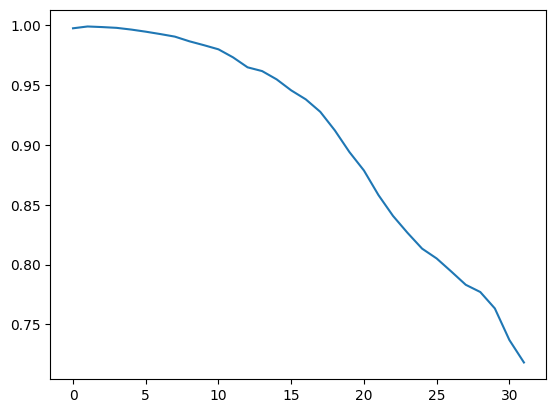

In [33]:
plt.plot(acc_vgg)

In [34]:
nc = ml.net_ches_2018(256, 8, 64, depth=20, output_activation='sigmoid')
nc.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [35]:
nc.fit(X,Y,epochs=101, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 46s 14ms/step - loss: 0.9773 - binary_accuracy: 0.5008 - val_loss: 0.7728 - val_binary_accuracy: 0.5012 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 38s 13ms/step - loss: 0.7566 - binary_accuracy: 0.5093 - val_loss: 0.7458 - val_binary_accuracy: 0.5159 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 39s 14ms/step - loss: 0.7376 - binary_accuracy: 0.5281 - val_loss: 0.7297 - val_binary_accuracy: 0.5323 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 39s 14ms/step - loss: 0.7203 - binary_accuracy: 0.5419 - val_loss: 0.7124 - val_binary_accuracy: 0.5443 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 40s 14ms/step - loss: 0.7043 - binary_accuracy: 0.5523 - val_loss: 0.6975 - val_binary_accuracy: 0.5571 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 38s 14ms/step - loss: 0.6907 - binary_accuracy: 0.568

In [36]:
Zt_nc = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 14s 4ms/step


In [37]:
Zt_nc_bin = Zt_nc > 0.5

In [38]:
acc_nc = np.mean(Zt_nc_bin == Yt, axis=0)

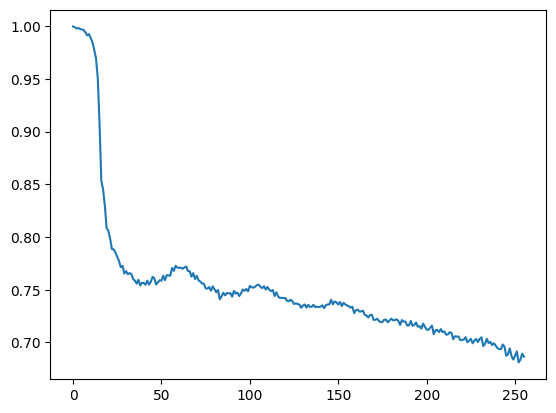

In [39]:
plt.plot(acc_nc)

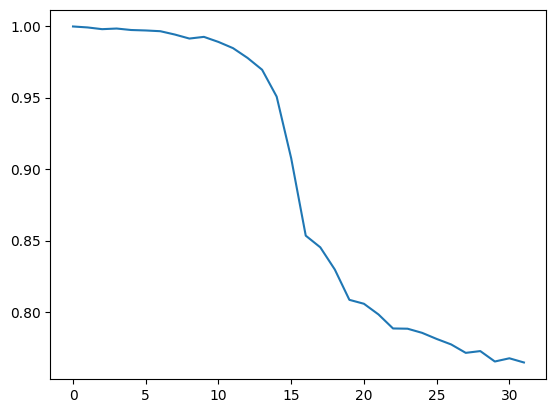

In [40]:
plt.plot(acc_nc[0:32])

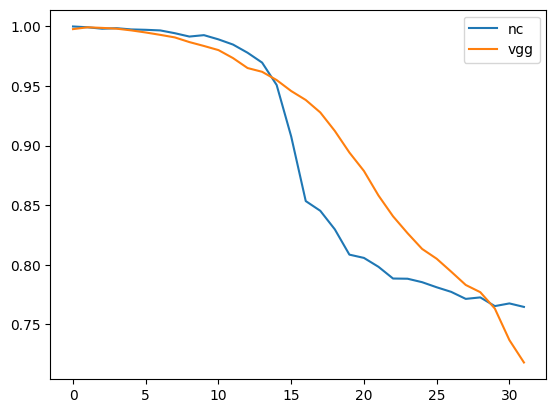

In [41]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg)
plt.legend(["nc","vgg"])

In [53]:
vgg_model = ml.VGG_1D(512, 256, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

In [54]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [55]:
vgg_model.fit(X,Y, epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 22s 7ms/step - loss: 0.8141 - binary_accuracy: 0.5032 - val_loss: 0.7963 - val_binary_accuracy: 0.5070 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 24s 8ms/step - loss: 0.7081 - binary_accuracy: 0.5463 - val_loss: 0.6812 - val_binary_accuracy: 0.5705 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6768 - binary_accuracy: 0.5775 - val_loss: 0.6714 - val_binary_accuracy: 0.5865 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6632 - binary_accuracy: 0.5988 - val_loss: 0.6506 - val_binary_accuracy: 0.6157 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6460 - binary_accuracy: 0.6192 - val_loss: 0.6395 - val_binary_accuracy: 0.6261 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6358 - binary_accuracy: 0.6297 - va

In [56]:
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

3125/3125 [==============================] - 4s 1ms/step


In [57]:
Zt_vgg_bin = Zt_vgg > 0.5

In [58]:
acc_vgg = np.mean(Zt_vgg_bin == Yt, axis=0)

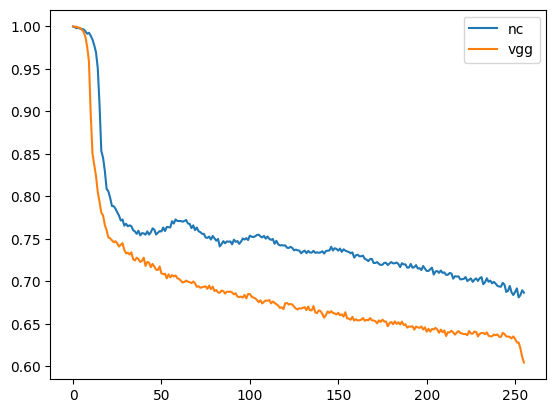

In [59]:
plt.plot(acc_nc)
plt.plot(acc_vgg)
plt.legend(['nc','vgg'])

In [60]:
nc.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 512)]                0         []                            
                                                                                                  
 reshape_5 (Reshape)         (None, 8, 64)                0         ['input_6[0][0]']             
                                                                                                  
 batch_normalization_35 (Ba  (None, 8, 64)                256       ['reshape_5[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 conv1d_20 (Conv1D)          (None, 8, 256)               16640     ['batch_normalization_35

In [62]:
vgg_model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 512)]             0         
                                                                 
 reshape_6 (Reshape)         (None, 512, 1)            0         
                                                                 
 conv1d_122 (Conv1D)         (None, 512, 32)           128       
                                                                 
 batch_normalization_132 (B  (None, 512, 32)           128       
 atchNormalization)                                              
                                                                 
 max_pooling1d_48 (MaxPooli  (None, 256, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_123 (Conv1D)         (None, 256, 64)           6208

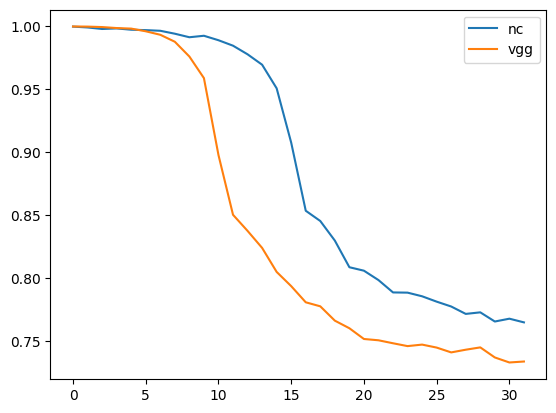

In [63]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg[0:32])
plt.legend(['nc','vgg'])

In [64]:
nc.fit(X,Y,epochs=21, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.5211 - binary_accuracy: 0.7333 - val_loss: 0.4958 - val_binary_accuracy: 0.7532 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 34s 12ms/step - loss: 0.5239 - binary_accuracy: 0.7314 - val_loss: 0.5040 - val_binary_accuracy: 0.7458 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.5283 - binary_accuracy: 0.7282 - val_loss: 0.4999 - val_binary_accuracy: 0.7504 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 35s 12ms/step - loss: 0.5336 - binary_accuracy: 0.7245 - val_loss: 0.5156 - val_binary_accuracy: 0.7377 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 33s 12ms/step - loss: 0.5371 - binary_accuracy: 0.7223 - val_loss: 0.5219 - val_binary_accuracy: 0.7336 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 35s 12ms/step - loss: 0.5419 - binary_accuracy: 0.7194 - va

In [65]:
Zt_nc2 = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 11s 3ms/step


In [66]:
Zt_nc2_bin = Zt_nc2 > 0.5

In [67]:
acc_nc2 = np.mean(Zt_nc2_bin == Yt, axis=0)

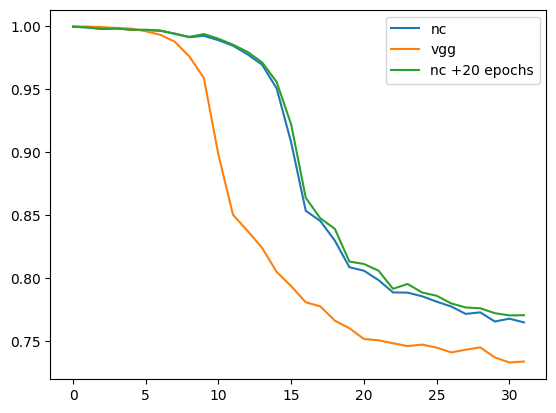

In [68]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg[0:32])
plt.plot(acc_nc2[0:32])
plt.legend(['nc','vgg','nc +20 epochs'])

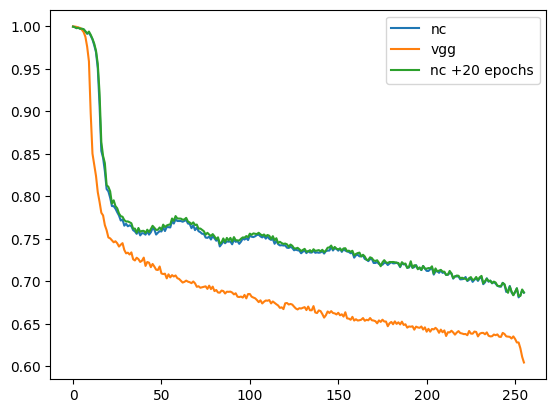

In [69]:
plt.plot(acc_nc)
plt.plot(acc_vgg)
plt.plot(acc_nc2)
plt.legend(['nc','vgg','nc +20 epochs'])

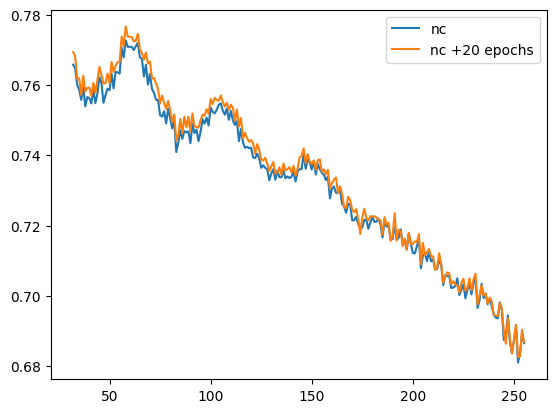

In [72]:
plt.plot(np.arange(32,256),acc_nc[32:])
plt.plot(np.arange(32,256),acc_nc2[32:])
plt.legend(['nc','nc +20 epochs'])

In [102]:
import Transformer
reload(Transformer)
model = Transformer.create_transformer_model((512,), 1, 128, 5, 64, output_activation='sigmoid',outputs=8, dense_nodes=512)

In [103]:
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_31 (InputLayer)       [(None, 512, 1)]          0         
                                                                 
 conv1d_135 (Conv1D)         (None, 512, 128)          2304      
                                                                 
 token_and_position_embeddi  (None, 512, 128)          82048     
 ng_8 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_62 (Tran  (None, 512, 128)          347072    
 sformerBlock)                                                   
                                                                 
 global_max_pooling1d_8 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [104]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
model.fit(X,Y[:,0:8],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.7030 - binary_accuracy: 0.5064 - val_loss: 0.6931 - val_binary_accuracy: 0.5109 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.4796 - binary_accuracy: 0.7366 - val_loss: 0.3531 - val_binary_accuracy: 0.8184 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.2266 - binary_accuracy: 0.8892 - val_loss: 0.0821 - val_binary_accuracy: 0.9664 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.0480 - binary_accuracy: 0.9804 - val_loss: 0.0352 - val_binary_accuracy: 0.9850 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 66s 23ms/step - loss: 0.0289 - binary_accuracy: 0.9884 - val_loss: 0.0287 - val_binary_accuracy: 0.9873 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.0267 - binary_accuracy: 0.9896 - va

In [105]:
model.fit(X,Y[:,8:16],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 61s 22ms/step - loss: 0.8896 - binary_accuracy: 0.5059 - val_loss: 1.5784 - val_binary_accuracy: 0.4994 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.5605 - binary_accuracy: 0.6483 - val_loss: 0.4984 - val_binary_accuracy: 0.7244 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.3265 - binary_accuracy: 0.8194 - val_loss: 0.2620 - val_binary_accuracy: 0.8613 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 61s 22ms/step - loss: 0.1785 - binary_accuracy: 0.9109 - val_loss: 0.0817 - val_binary_accuracy: 0.9643 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.0709 - binary_accuracy: 0.9673 - val_loss: 0.0488 - val_binary_accuracy: 0.9787 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 66s 23ms/step - loss: 0.0515 - binary_accuracy: 0.9757 - va

In [106]:
model.fit(X,Y[:,16:24],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 64s 23ms/step - loss: 1.0201 - binary_accuracy: 0.5081 - val_loss: 0.7707 - val_binary_accuracy: 0.5136 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.6250 - binary_accuracy: 0.6126 - val_loss: 0.7668 - val_binary_accuracy: 0.6510 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.4495 - binary_accuracy: 0.7446 - val_loss: 0.5374 - val_binary_accuracy: 0.7693 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.3265 - binary_accuracy: 0.8189 - val_loss: 0.3791 - val_binary_accuracy: 0.8463 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.2171 - binary_accuracy: 0.8846 - val_loss: 0.2143 - val_binary_accuracy: 0.9089 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 68s 24ms/step - loss: 0.1523 - binary_accuracy: 0.9173 - va

In [109]:
vgg_model = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [110]:
vgg_model.fit(X,Y[:,0:8],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.8172 - binary_accuracy: 0.5177 - val_loss: 0.7696 - val_binary_accuracy: 0.5365 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6472 - binary_accuracy: 0.6337 - val_loss: 0.5424 - val_binary_accuracy: 0.7053 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.4171 - binary_accuracy: 0.7854 - val_loss: 0.2968 - val_binary_accuracy: 0.8543 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.2315 - binary_accuracy: 0.8894 - val_loss: 0.1440 - val_binary_accuracy: 0.9346 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.1264 - binary_accuracy: 0.9456 - val_loss: 0.0779 - val_binary_accuracy: 0.9688 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.0779 - binary_accuracy: 0.9694 - val_loss

In [111]:
vgg_model.fit(X,Y[:,8:16],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 5.1936 - binary_accuracy: 0.5117 - val_loss: 3.0023 - val_binary_accuracy: 0.5286 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.9596 - binary_accuracy: 0.5545 - val_loss: 0.6842 - val_binary_accuracy: 0.5864 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6162 - binary_accuracy: 0.6386 - val_loss: 0.6869 - val_binary_accuracy: 0.7107 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.4946 - binary_accuracy: 0.7390 - val_loss: 0.4581 - val_binary_accuracy: 0.7849 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.4024 - binary_accuracy: 0.7971 - val_loss: 0.6761 - val_binary_accuracy: 0.8372 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.3312 - binary_accuracy: 0.8396 - val_loss

In [112]:
vgg_model.fit(X,Y[:,16:24],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 9ms/step - loss: 3.3721 - binary_accuracy: 0.5031 - val_loss: 2.4870 - val_binary_accuracy: 0.5076 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.9870 - binary_accuracy: 0.5320 - val_loss: 0.7508 - val_binary_accuracy: 0.5671 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6618 - binary_accuracy: 0.6014 - val_loss: 0.6282 - val_binary_accuracy: 0.6421 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5866 - binary_accuracy: 0.6734 - val_loss: 0.5675 - val_binary_accuracy: 0.7167 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5153 - binary_accuracy: 0.7289 - val_loss: 0.4882 - val_binary_accuracy: 0.7646 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.4546 - binary_accuracy: 0.7703 - val_loss

In [113]:
model.fit(X,Y[:,24:32],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 67s 24ms/step - loss: 1.0895 - binary_accuracy: 0.5019 - val_loss: 1.8602 - val_binary_accuracy: 0.5039 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.6757 - binary_accuracy: 0.5581 - val_loss: 3.3160 - val_binary_accuracy: 0.5284 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 62s 22ms/step - loss: 0.5807 - binary_accuracy: 0.6659 - val_loss: 1.6872 - val_binary_accuracy: 0.6188 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.4094 - binary_accuracy: 0.7750 - val_loss: 0.9099 - val_binary_accuracy: 0.7583 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.2534 - binary_accuracy: 0.8554 - val_loss: 0.6800 - val_binary_accuracy: 0.8335 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.2068 - binary_accuracy: 0.8841 - va

In [114]:
vgg_model.fit(X,Y[:,24:32],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 22s 8ms/step - loss: 2.2068 - binary_accuracy: 0.5065 - val_loss: 1.5273 - val_binary_accuracy: 0.5151 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8349 - binary_accuracy: 0.5452 - val_loss: 0.7405 - val_binary_accuracy: 0.5852 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6688 - binary_accuracy: 0.6104 - val_loss: 0.6518 - val_binary_accuracy: 0.6489 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6142 - binary_accuracy: 0.6629 - val_loss: 0.6005 - val_binary_accuracy: 0.6928 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.5733 - binary_accuracy: 0.6984 - val_loss: 0.5809 - val_binary_accuracy: 0.7236 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5361 - binary_accuracy: 0.7241 - val_loss

In [116]:
model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.8116 - binary_accuracy: 0.5040 - val_loss: 3.5154 - val_binary_accuracy: 0.5059 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.5790 - binary_accuracy: 0.6288 - val_loss: 4.0867 - val_binary_accuracy: 0.6034 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 62s 22ms/step - loss: 0.4656 - binary_accuracy: 0.7000 - val_loss: 3.3425 - val_binary_accuracy: 0.6427 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.4424 - binary_accuracy: 0.7105 - val_loss: 2.9307 - val_binary_accuracy: 0.6625 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.4287 - binary_accuracy: 0.7160 - val_loss: 2.9809 - val_binary_accuracy: 0.6855 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.6051 - binary_accuracy: 0.5723 - va

In [117]:
vgg_model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 21s 8ms/step - loss: 1.4712 - binary_accuracy: 0.5068 - val_loss: 1.1647 - val_binary_accuracy: 0.5167 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.7555 - binary_accuracy: 0.5589 - val_loss: 0.7337 - val_binary_accuracy: 0.6012 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6533 - binary_accuracy: 0.6261 - val_loss: 0.6393 - val_binary_accuracy: 0.6628 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6001 - binary_accuracy: 0.6735 - val_loss: 0.5628 - val_binary_accuracy: 0.7028 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5580 - binary_accuracy: 0.7075 - val_loss: 0.5305 - val_binary_accuracy: 0.7335 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5302 - binary_accuracy: 0.7272 - val_loss

In [118]:
vgg_model.summary()

Model: "model_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_33 (InputLayer)       [(None, 512)]             0         
                                                                 
 reshape_18 (Reshape)        (None, 512, 1)            0         
                                                                 
 conv1d_140 (Conv1D)         (None, 512, 32)           128       
                                                                 
 batch_normalization_146 (B  (None, 512, 32)           128       
 atchNormalization)                                              
                                                                 
 max_pooling1d_56 (MaxPooli  (None, 256, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_141 (Conv1D)         (None, 256, 64)           620

In [119]:
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_31 (InputLayer)       [(None, 512, 1)]          0         
                                                                 
 conv1d_135 (Conv1D)         (None, 512, 128)          2304      
                                                                 
 token_and_position_embeddi  (None, 512, 128)          82048     
 ng_8 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_62 (Tran  (None, 512, 128)          347072    
 sformerBlock)                                                   
                                                                 
 global_max_pooling1d_8 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [120]:
vgg_model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.2899 - binary_accuracy: 0.8746 - val_loss: 0.3474 - val_binary_accuracy: 0.8446 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 18s 6ms/step - loss: 0.2959 - binary_accuracy: 0.8714 - val_loss: 0.3523 - val_binary_accuracy: 0.8434 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.2970 - binary_accuracy: 0.8709 - val_loss: 0.3589 - val_binary_accuracy: 0.8416 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.3045 - binary_accuracy: 0.8669 - val_loss: 0.3623 - val_binary_accuracy: 0.8381 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 25s 9ms/step - loss: 0.3045 - binary_accuracy: 0.8670 - val_loss: 0.3837 - val_binary_accuracy: 0.8310 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.3086 - binary_accuracy: 0.8654 - val_loss

In [121]:
vgg_model.fit(X,Y[:,40:48],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 1.8404 - binary_accuracy: 0.5072 - val_loss: 1.4913 - val_binary_accuracy: 0.5143 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8391 - binary_accuracy: 0.5493 - val_loss: 0.7086 - val_binary_accuracy: 0.5911 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.6683 - binary_accuracy: 0.6165 - val_loss: 0.6760 - val_binary_accuracy: 0.6546 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6079 - binary_accuracy: 0.6706 - val_loss: 0.5754 - val_binary_accuracy: 0.7007 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 28s 10ms/step - loss: 0.5639 - binary_accuracy: 0.7053 - val_loss: 0.5281 - val_binary_accuracy: 0.7310 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 27s 9ms/step - loss: 0.5369 - binary_accuracy: 0.7239 - val_los

In [123]:
vgg_model2 = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model2.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
vgg_model2.fit(X,Y[:,40:48],epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8241 - binary_accuracy: 0.5119 - val_loss: 0.7871 - val_binary_accuracy: 0.5212 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 21s 8ms/step - loss: 0.7182 - binary_accuracy: 0.5594 - val_loss: 0.7052 - val_binary_accuracy: 0.5683 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6701 - binary_accuracy: 0.6030 - val_loss: 0.6712 - val_binary_accuracy: 0.6076 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6466 - binary_accuracy: 0.6285 - val_loss: 0.6437 - val_binary_accuracy: 0.6316 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6302 - binary_accuracy: 0.6450 - val_loss: 0.6200 - val_binary_accuracy: 0.6530 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6094 - binary_accuracy: 0.6632 - va

In [124]:
vgg_model.fit(X,Y[:,40:48],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3082 - binary_accuracy: 0.8660 - val_loss: 0.4199 - val_binary_accuracy: 0.8104 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.3126 - binary_accuracy: 0.8635 - val_loss: 0.4327 - val_binary_accuracy: 0.8077 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3172 - binary_accuracy: 0.8609 - val_loss: 0.4298 - val_binary_accuracy: 0.8067 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 25s 9ms/step - loss: 0.3186 - binary_accuracy: 0.8603 - val_loss: 0.4291 - val_binary_accuracy: 0.8069 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3219 - binary_accuracy: 0.8582 - val_loss: 0.4519 - val_binary_accuracy: 0.7956 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.3243 - binary_accuracy: 0.8578 - val_loss

In [125]:
vgg_model.fit(X,Y[:,48:56],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 23s 8ms/step - loss: 1.7086 - binary_accuracy: 0.5091 - val_loss: 1.4349 - val_binary_accuracy: 0.5148 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.8409 - binary_accuracy: 0.5466 - val_loss: 0.7251 - val_binary_accuracy: 0.5848 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6706 - binary_accuracy: 0.6135 - val_loss: 0.6592 - val_binary_accuracy: 0.6485 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6191 - binary_accuracy: 0.6596 - val_loss: 0.5809 - val_binary_accuracy: 0.6899 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.5786 - binary_accuracy: 0.6925 - val_loss: 0.5505 - val_binary_accuracy: 0.7167 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5525 - binary_accuracy: 0.7107 - val_loss

In [126]:
vgg_model.fit(X,Y[:,56:64],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 8ms/step - loss: 1.1682 - binary_accuracy: 0.5092 - val_loss: 1.0052 - val_binary_accuracy: 0.5168 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.7452 - binary_accuracy: 0.5605 - val_loss: 0.6813 - val_binary_accuracy: 0.6024 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6492 - binary_accuracy: 0.6280 - val_loss: 0.6183 - val_binary_accuracy: 0.6633 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6026 - binary_accuracy: 0.6702 - val_loss: 0.5764 - val_binary_accuracy: 0.6986 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.5712 - binary_accuracy: 0.6949 - val_loss: 0.5423 - val_binary_accuracy: 0.7169 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.5506 - binary_accuracy: 0.7097 - val_loss

In [127]:
vgg_model.fit(X,Y[:,64:72],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 25s 9ms/step - loss: 1.0685 - binary_accuracy: 0.5120 - val_loss: 0.9522 - val_binary_accuracy: 0.5228 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.7258 - binary_accuracy: 0.5655 - val_loss: 0.8493 - val_binary_accuracy: 0.6099 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6475 - binary_accuracy: 0.6281 - val_loss: 0.6601 - val_binary_accuracy: 0.6660 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6034 - binary_accuracy: 0.6676 - val_loss: 0.5845 - val_binary_accuracy: 0.6995 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5728 - binary_accuracy: 0.6923 - val_loss: 0.5330 - val_binary_accuracy: 0.7204 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.5545 - binary_accuracy: 0.7065 - val_loss

In [128]:
vgg_model.fit(X,Y[:,72:80],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 1.0477 - binary_accuracy: 0.5116 - val_loss: 0.9616 - val_binary_accuracy: 0.5197 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.7285 - binary_accuracy: 0.5610 - val_loss: 0.7271 - val_binary_accuracy: 0.6022 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6448 - binary_accuracy: 0.6279 - val_loss: 0.7072 - val_binary_accuracy: 0.6637 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6004 - binary_accuracy: 0.6683 - val_loss: 0.5726 - val_binary_accuracy: 0.6978 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.5751 - binary_accuracy: 0.6893 - val_loss: 0.5480 - val_binary_accuracy: 0.7100 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5560 - binary_accuracy: 0.7031 - val_loss

In [4]:
unet = ml.unet_1d(512, output_size=512,output_channels=3, output_activation='softmax')

2025-01-23 13:47:54.584001: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 13:47:54.616740: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 13:47:54.616866: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [5]:
from experiments import synthetic_data_alignment_clean
X,Y = synthetic_data_alignment_clean(num_samples=10**4, num_features=32, seq_length=512, noise=0.0)

In [6]:
print(X.shape)
print(Y.shape)
print(X[0][0:32])
print(Y[0])

(10000, 512)
(10000, 32)
[2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0]


In [7]:
from keras.layers import Lambda, Input
# Add CTC loss configuration
def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return K.ctc_batch_cost(labels, y_pred, input_length, label_length)

# Create input tensors for CTC
labels = Input(name='labels', shape=(32,), dtype='float32')  # Your target sequence length is 32
input_length = Input(name='input_length', shape=(1,))
label_length = Input(name='label_length', shape=(1,))

# Define loss output
loss_out = Lambda(ctc_lambda_func, output_shape=(1,), name='ctc')([unet.output, labels, input_length, label_length])

# Create training model
model = Model(inputs=[unet.input, labels, input_length, label_length], outputs=loss_out)

# Compile with dummy loss since actual loss is added as a lambda layer
model.compile(optimizer='adam', loss={'ctc': lambda y_true, y_pred: y_pred})

In [8]:
# Prepare the input data for CTC
input_length = np.ones((X.shape[0], 1)) * 512  # Full length of input sequences
label_length = np.ones((Y.shape[0], 1)) * Y.shape[1]  # Length of label sequences

print(label_length)

# Create inputs dictionary
train_inputs = {
    'input_1': X,  # Main input data
    'labels': Y,   # Label data
    'input_length': input_length,
    'label_length': label_length
}

# Create dummy output data (CTC loss is computed internally)
train_outputs = {'ctc': np.zeros(X.shape[0])}  

# Modified fit call
model.fit(
    train_inputs,
    train_outputs,
    epochs=101,
    batch_size=32,
    validation_split=0.1,
    callbacks=[lr_cyclic]
)

[[32.]
 [32.]
 [32.]
 ...
 [32.]
 [32.]
 [32.]]
Epoch 1/101


2025-01-23 13:48:03.459526: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-01-23 13:48:04.953170: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c599bf11380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-01-23 13:48:04.953183: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-01-23 13:48:04.955866: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1737593285.009035   46186 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 [==============================] - 25s 58ms/step - loss: 100.7093 - val_loss: 147.2079 - lr: 1.0000e-05
Epoch 2/101
282/282 [==============================] - 13s 46ms/step - loss: 26.8951 - val_loss: 90.5222 - lr: 1.0900e-04
Epoch 3/101
282/282 [==============================] - 13s 47ms/step - loss: 22.8355 - val_loss: 78.1952 - lr: 2.0800e-04
Epoch 4/101
282/282 [==============================] - 13s 46ms/step - loss: 18.0983 - val_loss: 16.0018 - lr: 3.0700e-04
Epoch 5/101
282/282 [==============================] - 13s 47ms/step - loss: 9.4900 - val_loss: 10.5571 - lr: 4.0600e-04
Epoch 6/101
282/282 [==============================] - 13s 45ms/step - loss: 4.9497 - val_loss: 3.4509 - lr: 5.0500e-04
Epoch 7/101
282/282 [==============================] - 13s 45ms/step - loss: 5.1725 - val_loss: 2.5665 - lr: 6.0400e-04
Epoch 8/101
282/282 [==============================] - 13s 46ms/step - loss: 2.2742 - val_loss: 2.2059 - lr: 7.0300e-04
Epoch 9/101
282/282 [====================

313/313 [==============================] - 2s 6ms/step


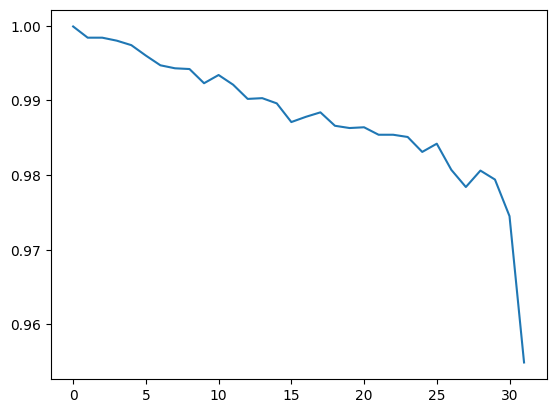

In [13]:
X_test, Y_test = synthetic_data_alignment_clean(num_samples=10**4, num_features=32, seq_length=512, noise=0.0)
Z_test = unet.predict(X_test, batch_size=32)
# ctc decode the predictions, each for 32 features, greedily
Z_test_decoded = K.ctc_decode(Z_test, input_length=np.ones(Z_test.shape[0])*512, greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:,0:32]
acc_test = np.mean(Z_test_decoded == Y_test, axis=0)
plt.plot(acc_test)


Epoch 1/101
282/282 [==============================] - 4s 7ms/step - loss: 0.8708 - binary_accuracy: 0.5055 - val_loss: 0.8555 - val_binary_accuracy: 0.5060 - lr: 1.0000e-05
Epoch 2/101
282/282 [==============================] - 2s 8ms/step - loss: 0.7710 - binary_accuracy: 0.5549 - val_loss: 0.8267 - val_binary_accuracy: 0.5354 - lr: 1.0900e-04
Epoch 3/101
282/282 [==============================] - 2s 8ms/step - loss: 0.6580 - binary_accuracy: 0.6307 - val_loss: 0.7032 - val_binary_accuracy: 0.6026 - lr: 2.0800e-04
Epoch 4/101
282/282 [==============================] - 2s 7ms/step - loss: 0.5956 - binary_accuracy: 0.6797 - val_loss: 0.6966 - val_binary_accuracy: 0.6111 - lr: 3.0700e-04
Epoch 5/101
282/282 [==============================] - 2s 6ms/step - loss: 0.5437 - binary_accuracy: 0.7225 - val_loss: 0.7023 - val_binary_accuracy: 0.6144 - lr: 4.0600e-04
Epoch 6/101
282/282 [==============================] - 3s 9ms/step - loss: 0.5024 - binary_accuracy: 0.7520 - val_loss: 0.7288 - v

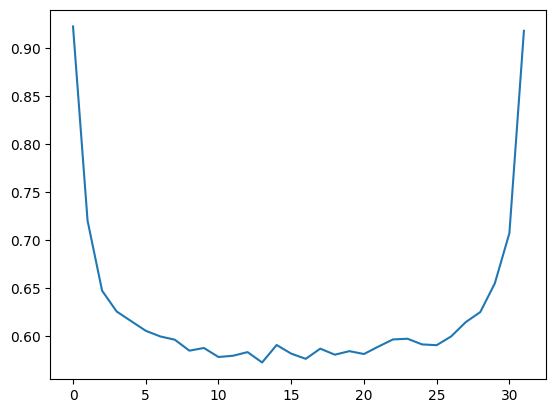

In [15]:
vgg_model_clean = ml.VGG_1D(512, 32, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model_clean.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
vgg_model_clean.fit(X,Y,epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])
Z_test_vgg = vgg_model_clean.predict(X_test,batch_size=32)
Z_test_vgg_bin = Z_test_vgg > 0.5
acc_test_vgg = np.mean(Z_test_vgg_bin == Y_test, axis=0)
plt.plot(acc_test_vgg)


In [20]:
from experiments import train_unet_ctc
train_unet_ctc(X,Y,epochs=21,batch_size=32)

Epoch 1/21
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5ac35eeef0>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5ac35eeef0>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
282/282 [==============================] - 18s 47ms/step - loss: 112.3909 - val_loss: 141.7766 - lr: 1.0000e-05
Epoch 2/21
282/282 [==============================] - 13s 45ms/step - loss: 30.0269 - val_loss: 41.0886 - lr: 1.0900e-04
Epoch 3/21
282/282 [==============================] - 13s 45ms/step - loss: 25.0280 - val_loss: 48.6434 - lr: 2.0800e-04
Epoch 4/21
282/282 [==============================] - 12s 44ms/step

(<keras.src.engine.functional.Functional at 0x7c5ac2bd31c0>,
 <keras.src.callbacks.History at 0x7c5ac21005b0>)

In [21]:
unet2, history = _

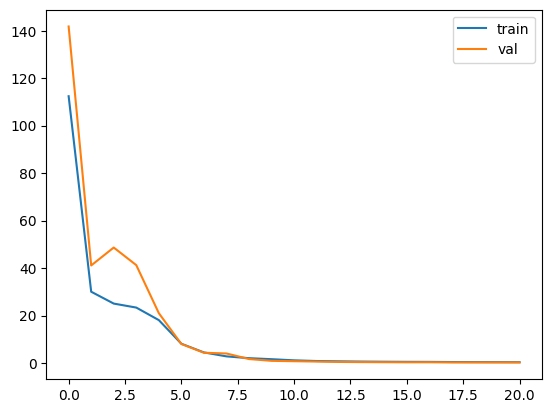

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])


In [ ]:
import numpy as np
from processing import resize_data

# TODO: The CM1 dataset is not included in this repository.
# You must obtain the CM1 data yourself, downsample it to the target size
# using processing.resize_data, and update the path below accordingly.
CM1_DATA_DIR = '../data/cm1'  # <-- update this path to point to your CM1 data

# Load the CM1 data
data = np.load(f'{CM1_DATA_DIR}/Test_all_50000.npz')
data2 = np.load(f'{CM1_DATA_DIR}/hold_first5648_50000.npz')

# Extract X and Y from the data
X, Y = data['X'], data['Y']
Xh, Yh = data2['X'], data2['Y']

# Downsample each trace to 1000 points
X_downsampled = resize_data(X, 1000)
Xh_downsampled = resize_data(Xh, 1000)

print(f"Original shape: {X.shape} -> Downsampled shape: {X_downsampled.shape}")
print(f"Original hold shape: {Xh.shape} -> Downsampled hold shape: {Xh_downsampled.shape}")

100%|██████████| 5648/5648 [00:01<00:00, 5452.27it/s]

Original shape: (2048, 50000) -> Downsampled shape: (2048, 1000)
Original hold shape: (5648, 50000) -> Downsampled hold shape: (5648, 1000)


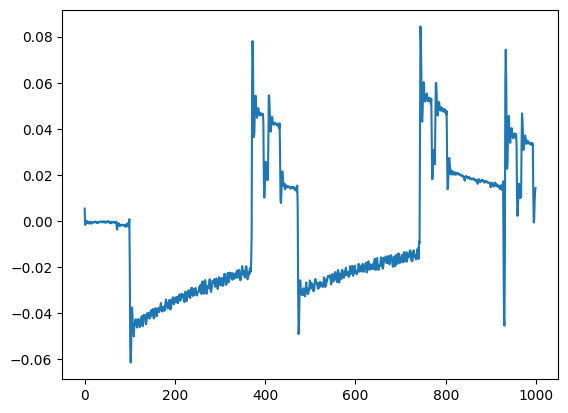

In [27]:
plt.plot(Xh_downsampled[0])

In [46]:
# resample both to 2000 points to get more space
X_downsampled2 = resize_data(X, 5000)
Xh_downsampled2 = resize_data(Xh, 5000)


100%|██████████| 5648/5648 [00:01<00:00, 4875.49it/s]


Epoch 1/101
159/159 [==============================] - 68s 373ms/step - loss: 442.4424 - val_loss: 378.5094 - lr: 1.0000e-05
Epoch 2/101
159/159 [==============================] - 58s 367ms/step - loss: 376.1258 - val_loss: 394.8671 - lr: 1.0900e-04
Epoch 3/101
159/159 [==============================] - 58s 366ms/step - loss: 369.3555 - val_loss: 377.6746 - lr: 2.0800e-04
Epoch 4/101
159/159 [==============================] - 58s 366ms/step - loss: 367.1010 - val_loss: 370.2608 - lr: 3.0700e-04
Epoch 5/101
159/159 [==============================] - 58s 366ms/step - loss: 366.1466 - val_loss: 372.5779 - lr: 4.0600e-04
Epoch 6/101
159/159 [==============================] - 58s 366ms/step - loss: 365.6747 - val_loss: 369.3031 - lr: 5.0500e-04
Epoch 7/101
159/159 [==============================] - 59s 368ms/step - loss: 365.3480 - val_loss: 372.3239 - lr: 6.0400e-04
Epoch 8/101
159/159 [==============================] - 58s 368ms/step - loss: 365.1452 - val_loss: 367.8877 - lr: 7.0300e-04


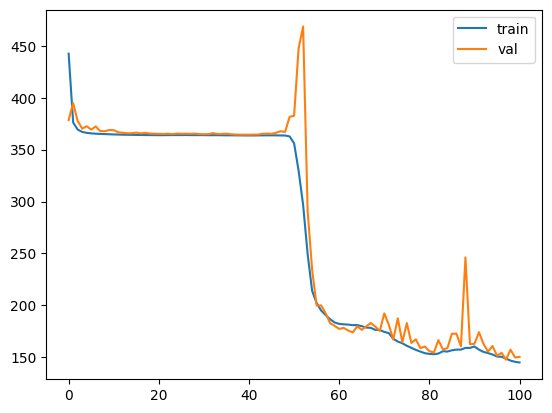

In [48]:
unet3, history = train_unet_ctc(Xh_downsampled, Yh, epochs=101, seq_length=2000, num_features=512, batch_size=32)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])


64/64 [==============================] - 1s 12ms/step


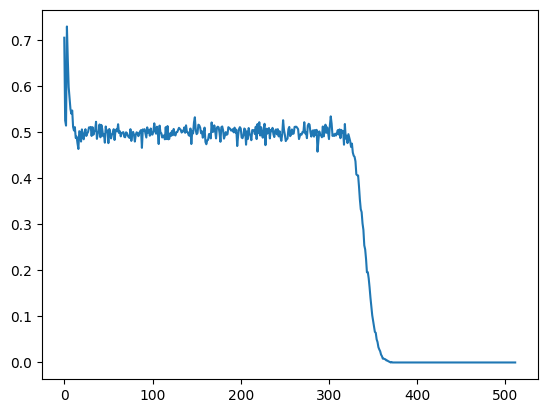

In [49]:
# Evaluate the model on the test data
# Get actual sequence length from input shape
seq_length = X_downsampled.shape[1]  # Should be 2000
num_features = Y.shape[1]  # Number of features in Y

# Predict and decode with correct sequence length
Z_test = unet3.predict(X_downsampled, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * seq_length,  # Use 2000 instead of 1000
                             greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:num_features]
acc_test = np.mean(Z_test_decoded == Y, axis=0)
plt.plot(acc_test)


Text(0.5, 1.0, 'CTC Probabilities vs Power Trace')

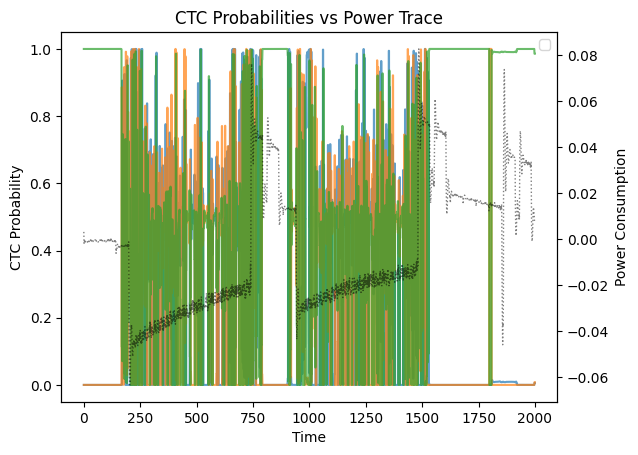

In [51]:
# Create figure and axis
fig, ax1 = plt.subplots()

# Plot CTC probabilities on first y-axis
ax1.plot(Z_test[0], alpha=0.7)
ax1.set_ylabel('CTC Probability')
ax1.set_xlabel('Time')

# Create second y-axis and plot power trace
ax2 = ax1.twinx()
ax2.plot(X_downsampled[0], 'k:', alpha=0.5, linewidth=1)
ax2.set_ylabel('Power Consumption')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, ['0', '1', 'blank', 'Power Trace'], loc='upper right')

plt.title('CTC Probabilities vs Power Trace')

In [52]:
unet3.save('unet3_test.keras')

Epoch 1/101
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5a6a673250>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5a6a673250>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
159/159 [==============================] - 67s 368ms/step - loss: 144.8250 - val_loss: 151.4430 - lr: 1.0000e-05
Epoch 2/101
159/159 [==============================] - 58s 365ms/step - loss: 145.2911 - val_loss: 150.1248 - lr: 1.0900e-04
Epoch 3/101
159/159 [==============================] - 58s 366ms/step - loss: 146.0300 - val_loss: 170.8729 - lr: 2.0800e-04
Epoch 4/101
159/159 [==============================] - 58

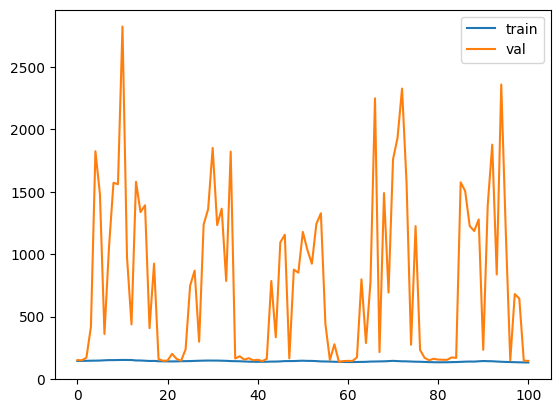

In [54]:
unet3, history = train_unet_ctc(Xh_downsampled, Yh, epochs=101, seq_length=2000, num_features=512, batch_size=32, unet=unet3)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])

64/64 [==============================] - 1s 11ms/step


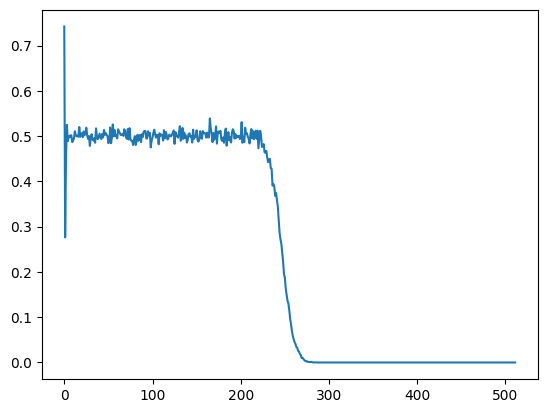

In [55]:
# Evaluate the model on the test data
# Get actual sequence length from input shape
seq_length = X_downsampled.shape[1]  # Should be 2000
num_features = Y.shape[1]  # Number of features in Y

# Predict and decode with correct sequence length
Z_test = unet3.predict(X_downsampled, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * seq_length,  # Use 2000 instead of 1000
                             greedy=False, beam_width=100)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:num_features]
acc_test = np.mean(Z_test_decoded == Y, axis=0)
plt.plot(acc_test)


Text(0.5, 1.0, 'CTC Probabilities vs Power Trace')

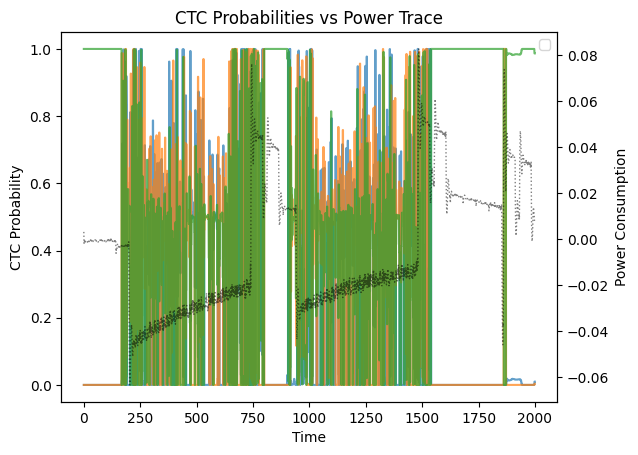

In [56]:
# Create figure and axis
fig, ax1 = plt.subplots()

# Plot CTC probabilities on first y-axis
ax1.plot(Z_test[0], alpha=0.7)
ax1.set_ylabel('CTC Probability')
ax1.set_xlabel('Time')

# Create second y-axis and plot power trace
ax2 = ax1.twinx()
ax2.plot(X_downsampled[0], 'k:', alpha=0.5, linewidth=1)
ax2.set_ylabel('Power Consumption')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, ['0', '1', 'blank', 'Power Trace'], loc='upper right')

plt.title('CTC Probabilities vs Power Trace')

In [57]:
unet3, history = train_unet_ctc(Xh_downsampled, Yh, epochs=101, seq_length=2000, num_features=512, batch_size=32, unet=unet3, min_learning_rate=1e-6, learning_rate=1e-5)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])

Epoch 1/101
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5a6856e050>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5a6856e050>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
159/159 [==============================] - 68s 369ms/step - loss: 132.5471 - val_loss: 145.3269 - lr: 1.0000e-06
Epoch 2/101
159/159 [==============================] - 58s 366ms/step - loss: 132.5466 - val_loss: 145.1953 - lr: 1.9000e-06
Epoch 3/101
159/159 [==============================] - 58s 365ms/step - loss: 132.4393 - val_loss: 144.8586 - lr: 2.8000e-06
Epoch 4/101
159/159 [==============================] - 58

KeyboardInterrupt: 

In [63]:
Yh_ext = np.array([np.concatenate([np.array([2]),Yh[i][0:256],np.array([3,3,4]),Yh[i][256:512],np.array([3,3,4])]) for i in range(Yh.shape[0])])
unet4, history = train_unet_ctc(Xh_downsampled, Yh_ext, epochs=101, seq_length=2000, num_features=519, batch_size=32, min_learning_rate=1e-5, learning_rate=5e-4, output_channels=6)


Epoch 1/101
159/159 [==============================] - 68s 373ms/step - loss: 1684.5638 - val_loss: 4136.7114 - lr: 1.0000e-05
Epoch 2/101
159/159 [==============================] - 58s 368ms/step - loss: 706.5976 - val_loss: 6853.1099 - lr: 5.9000e-05
Epoch 3/101
159/159 [==============================] - 58s 366ms/step - loss: 553.6805 - val_loss: 6080.3770 - lr: 1.0800e-04
Epoch 4/101
159/159 [==============================] - 58s 362ms/step - loss: 494.1953 - val_loss: 2907.5464 - lr: 1.5700e-04
Epoch 5/101
159/159 [==============================] - 58s 364ms/step - loss: 461.2838 - val_loss: 815.0012 - lr: 2.0600e-04
Epoch 6/101
159/159 [==============================] - 58s 365ms/step - loss: 439.6841 - val_loss: 448.7292 - lr: 2.5500e-04
Epoch 7/101
159/159 [==============================] - 59s 370ms/step - loss: 423.2017 - val_loss: 499.3284 - lr: 3.0400e-04
Epoch 8/101
159/159 [==============================] - 59s 371ms/step - loss: 407.8002 - val_loss: 422.3647 - lr: 3.5300

In [64]:
unet4.save('unet4_test.keras')

In [65]:
Y_ext = np.array([np.concatenate([np.array([2]),Y[i][0:256],np.array([3,3,4]),Y[i][256:512],np.array([3,3,4])]) for i in range(Y.shape[0])])

In [66]:
Y_ext[0]

array([2, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 3, 3, 4, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,

64/64 [==============================] - 1s 12ms/step


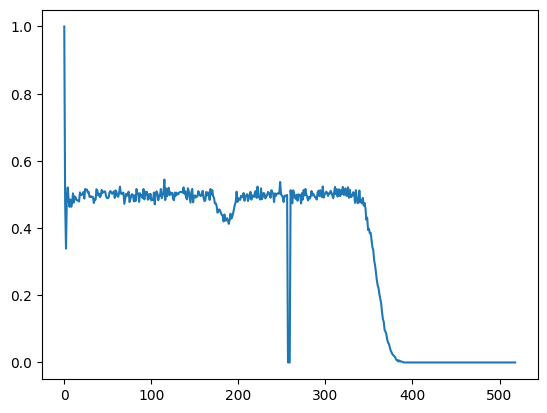

In [82]:
Z_test = unet4.predict(X_downsampled, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * seq_length,  # Use 2000 instead of 1000
                             greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:519]
acc_test = np.mean(Z_test_decoded == Y_ext, axis=0)
plt.plot(acc_test)

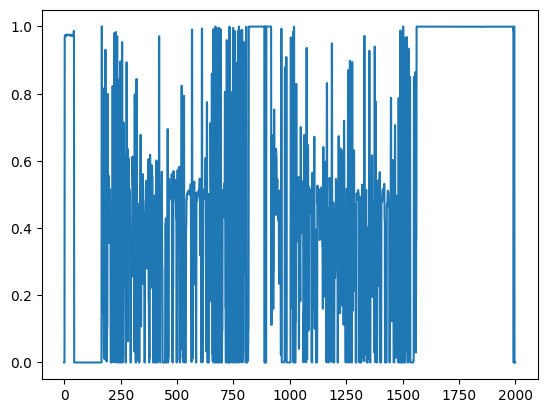

In [79]:
plt.plot(Z_test[0][:,5])

Epoch 1/501
58/58 [==============================] - 33s 431ms/step - loss: 131.8665 - val_loss: 130.9711 - lr: 1.0000e-05
Epoch 2/501
58/58 [==============================] - 21s 364ms/step - loss: 132.0732 - val_loss: 134.1379 - lr: 5.9000e-05
Epoch 3/501
58/58 [==============================] - 21s 359ms/step - loss: 132.3831 - val_loss: 149.6320 - lr: 1.0800e-04
Epoch 4/501
58/58 [==============================] - 21s 358ms/step - loss: 133.3234 - val_loss: 158.4358 - lr: 1.5700e-04
Epoch 5/501
58/58 [==============================] - 21s 357ms/step - loss: 135.9205 - val_loss: 190.2269 - lr: 2.0600e-04
Epoch 6/501
58/58 [==============================] - 21s 358ms/step - loss: 135.9749 - val_loss: 1516.6539 - lr: 2.5500e-04
Epoch 7/501
58/58 [==============================] - 21s 356ms/step - loss: 137.7102 - val_loss: 1645.7018 - lr: 3.0400e-04
Epoch 8/501
58/58 [==============================] - 21s 358ms/step - loss: 138.5717 - val_loss: 485.0060 - lr: 3.5300e-04
Epoch 9/501
58

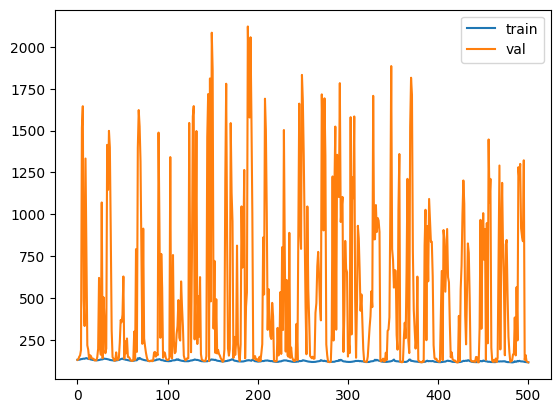

In [83]:
unet4b, history = train_unet_ctc(X_downsampled, Y_ext, epochs=501, seq_length=2000, num_features=519, batch_size=32, unet=unet4, min_learning_rate=1e-5, learning_rate=5e-4, output_channels=6)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])


64/64 [==============================] - 1s 12ms/step


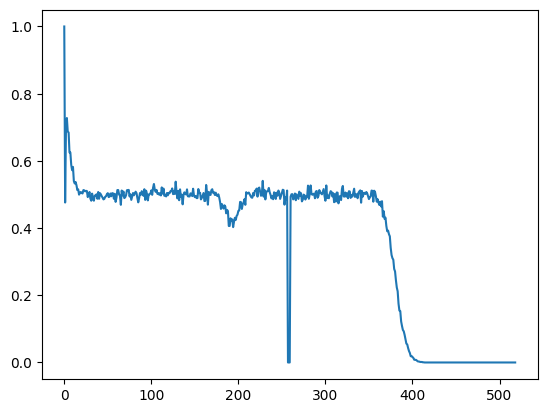

In [84]:
Z_test = unet4b.predict(X_downsampled, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * seq_length,  # Use 2000 instead of 1000
                             greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:519]
acc_test = np.mean(Z_test_decoded == Y_ext, axis=0)
plt.plot(acc_test)

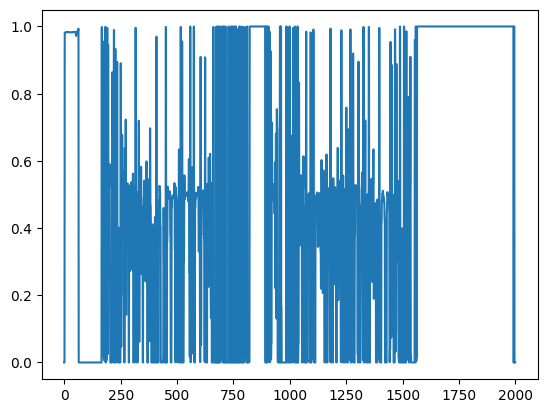

In [92]:
plt.plot(Z_test[0][:,5])

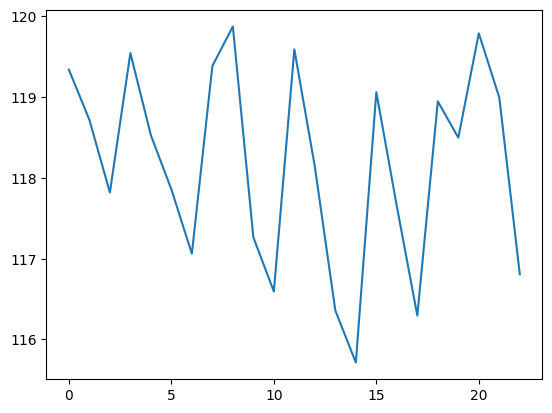

In [102]:
plt.plot(np.array(history.history['val_loss'])[np.array(history.history['val_loss']) < 120])

In [103]:
np.argmin(history.history['val_loss'])

422

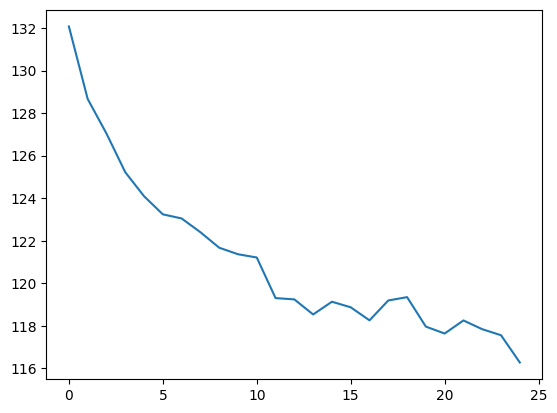

In [98]:
plt.plot(history.history['loss'][1:502:20])

In [104]:
from seglib import *

Segmentation Report
Mean Segment Length: 270.5201837144206
Standard Deviation of Segment Lengths: 240.0723757411444
Long Segments:
Short Segments:


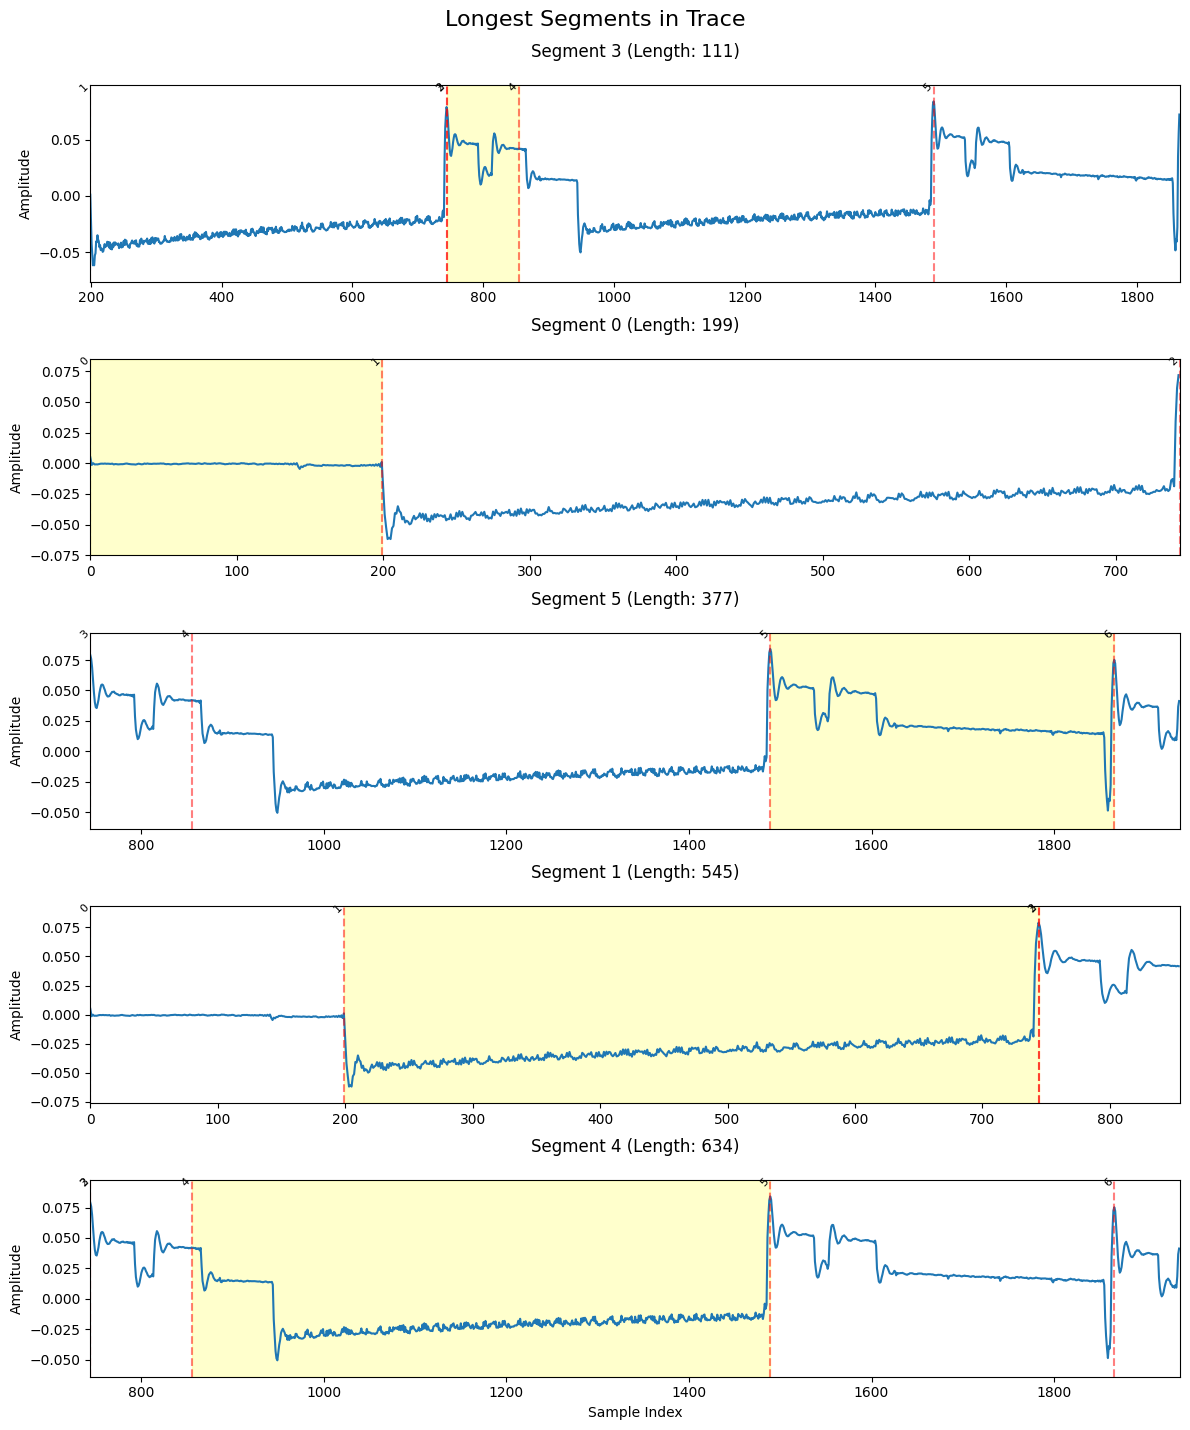

In [132]:
seg_points = auto_segment(Xh_downsampled, 3.0, 100, 100)
show_longest_segments(Xh_downsampled[0], seg_points[0])


In [133]:
seg_points[0]

[0, 199, 744, 744, 855, 1489, 1866, 1938]

In [134]:
seg_points[1]

[0, 199, 744, 816, 864, 1487, 1487, 1866]

In [135]:
seg_points[2]

[0, 141, 744, 744, 863, 1485, 1485, 1863]

In [136]:
v = [len(x) for x in seg_points]

In [137]:
np.max(v), np.min(v), np.mean(v), np.std(v)

(9, 6, 8.090474504249292, 0.8188172402085305)

In [138]:
np.argmax(v)

3

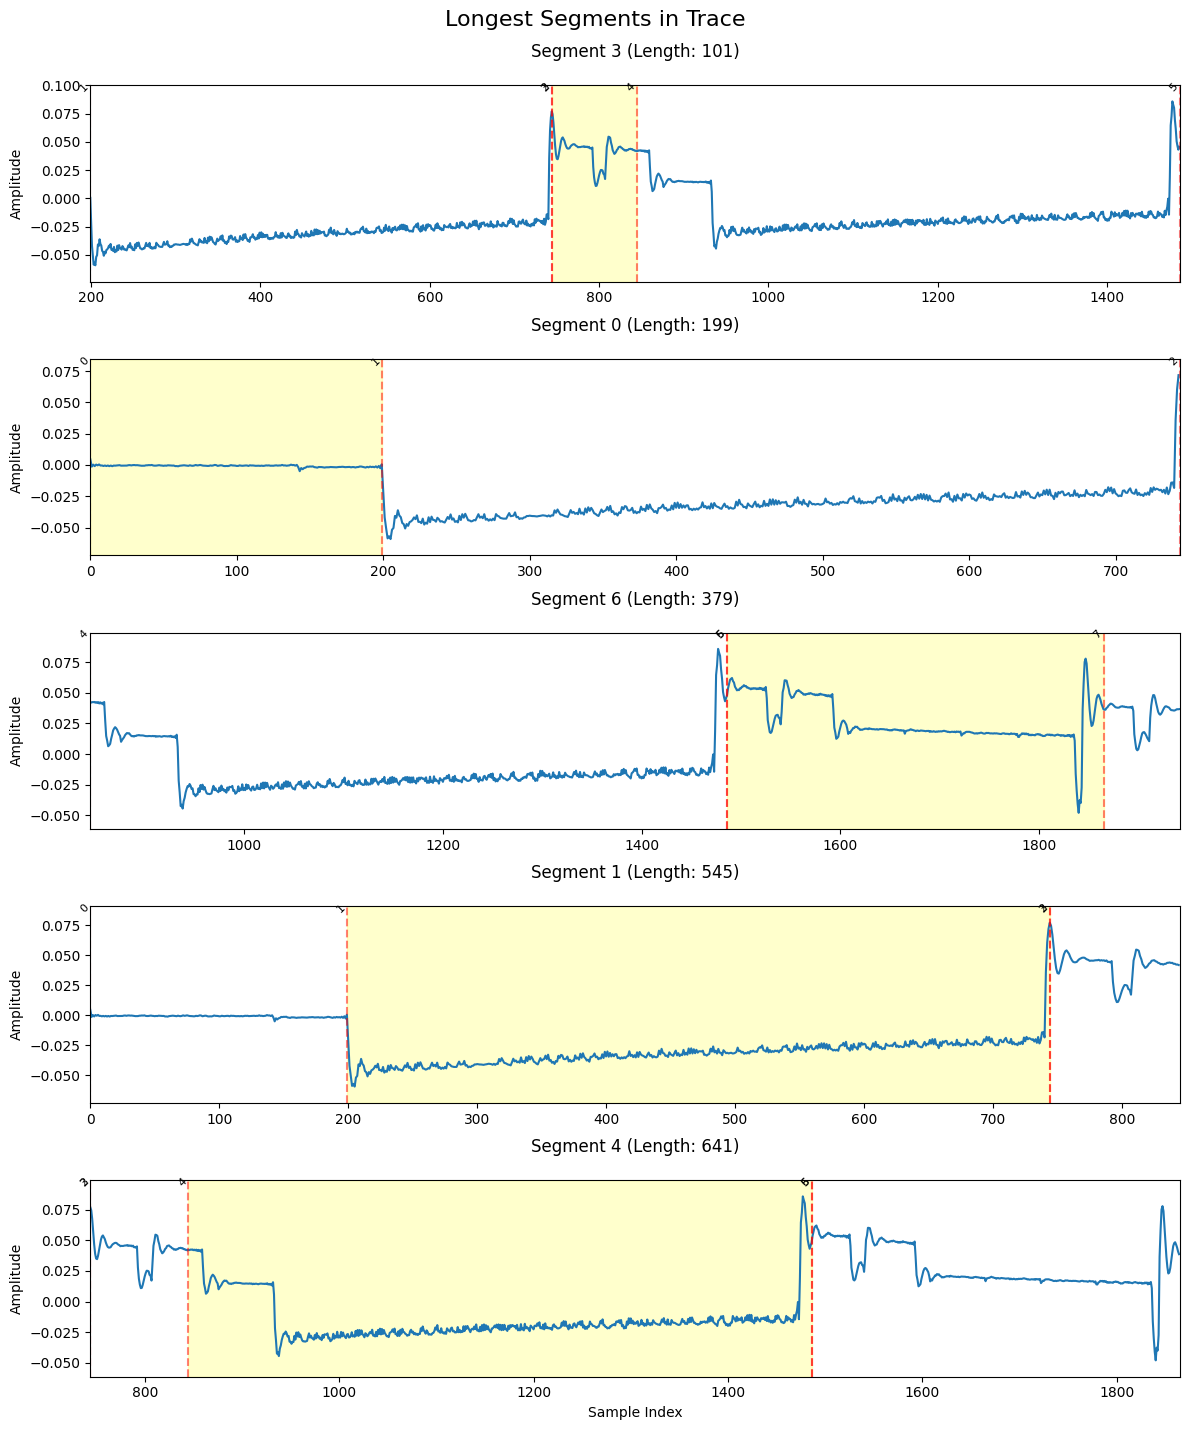

In [139]:
show_longest_segments(Xh_downsampled[15], seg_points[3])

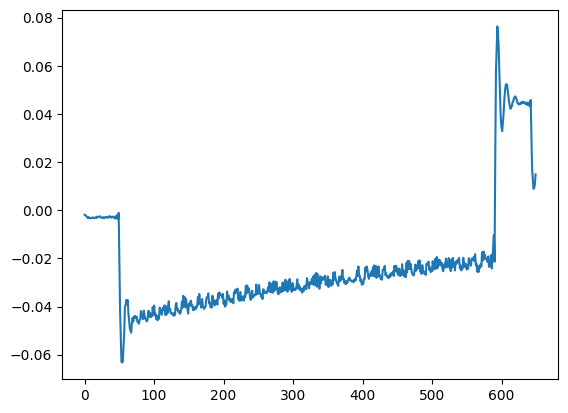

In [140]:
T = X_downsampled[:,150:800]
plt.plot(T[0])

In [141]:
T_resample = resize_data(T, 1000)

100%|██████████| 2048/2048 [00:00<00:00, 54215.35it/s]


In [142]:
Th = Xh_downsampled[:,150:800]
Th_resample = resize_data(Th, 1000)


100%|██████████| 5648/5648 [00:00<00:00, 53244.00it/s]


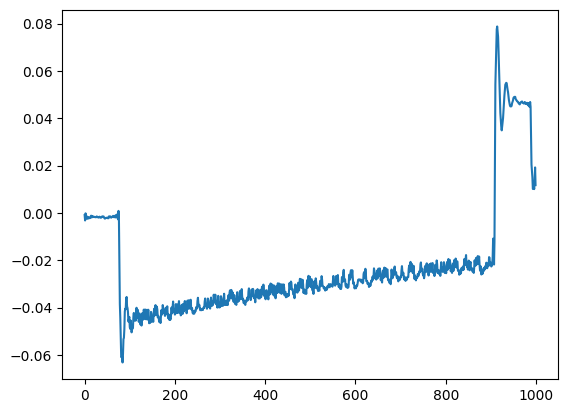

In [143]:
plt.plot(Th_resample[0])

In [144]:
Yh256 = Yh[:,0:256]
unet_seg = train_unet_ctc(Th_resample, Yh256, epochs=101, seq_length=1000, num_features=256, batch_size=32, min_learning_rate=1e-5, learning_rate=5e-4, output_channels=3)

Epoch 1/101
159/159 [==============================] - 29s 145ms/step - loss: 239.0335 - val_loss: 517.3928 - lr: 1.0000e-05
Epoch 2/101
159/159 [==============================] - 23s 147ms/step - loss: 200.0747 - val_loss: 419.1096 - lr: 5.9000e-05
Epoch 3/101
159/159 [==============================] - 23s 144ms/step - loss: 187.2358 - val_loss: 263.3174 - lr: 1.0800e-04
Epoch 4/101
159/159 [==============================] - 23s 145ms/step - loss: 147.8150 - val_loss: 175.4722 - lr: 1.5700e-04
Epoch 5/101
159/159 [==============================] - 22s 141ms/step - loss: 87.5650 - val_loss: 300.6037 - lr: 2.0600e-04
Epoch 6/101
159/159 [==============================] - 22s 141ms/step - loss: 48.6885 - val_loss: 85.7525 - lr: 2.5500e-04
Epoch 7/101
159/159 [==============================] - 23s 145ms/step - loss: 31.0708 - val_loss: 46.4011 - lr: 3.0400e-04
Epoch 8/101
159/159 [==============================] - 23s 144ms/step - loss: 25.5133 - val_loss: 39.3094 - lr: 3.5300e-04
Epoch 9

In [147]:
unet_seg, history = unet_seg


TypeError: cannot unpack non-iterable Functional object

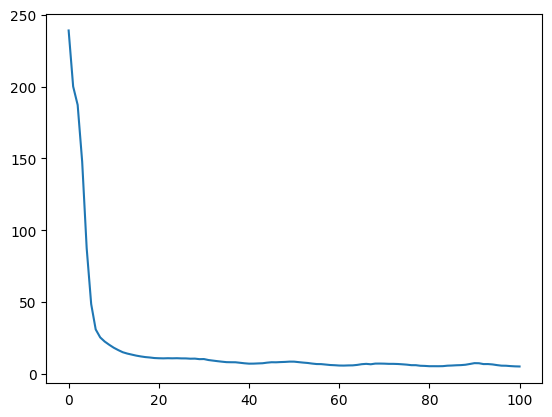

In [148]:

plt.plot(history.history['loss'])

64/64 [==============================] - 0s 7ms/step


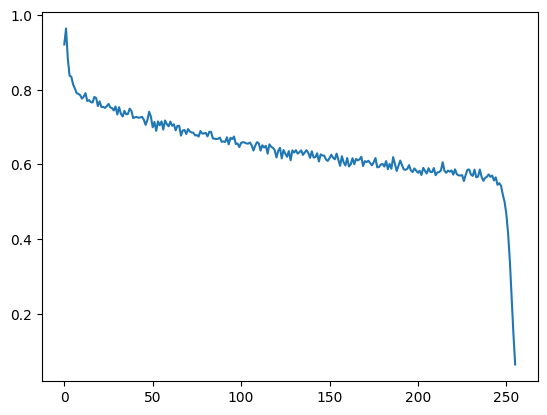

In [153]:
Y256 = Y[:,0:256]
Z_test = unet_seg.predict(T_resample, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * 1000,
                             greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:256]
acc_test = np.mean(Z_test_decoded == Y256, axis=0)
plt.plot(acc_test)


In [154]:
Y256[17,0:10]

array([1, 1, 1, 0, 1, 0, 1, 1, 0, 1])

In [156]:
Z_test_decoded[17,0:10]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [160]:
np.sum(Z_test_decoded[0][0:200] ^ Y256[0][0:200])


19

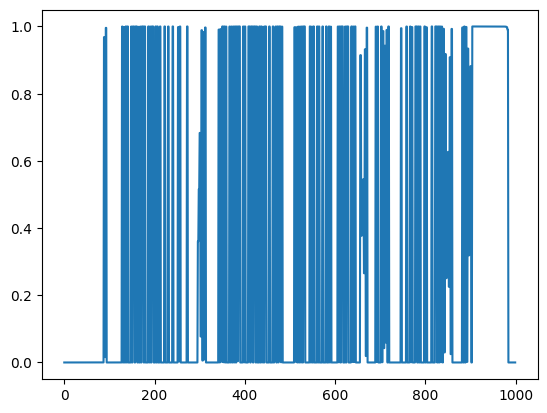

In [165]:
plt.plot(Z_test[17][:,0])

Mean Levenshtein similarity: 98.28
Std dev Levenshtein similarity: 1.20
Min Levenshtein similarity: 93.00
Max Levenshtein similarity: 100.00


Text(0, 0.5, 'Count')

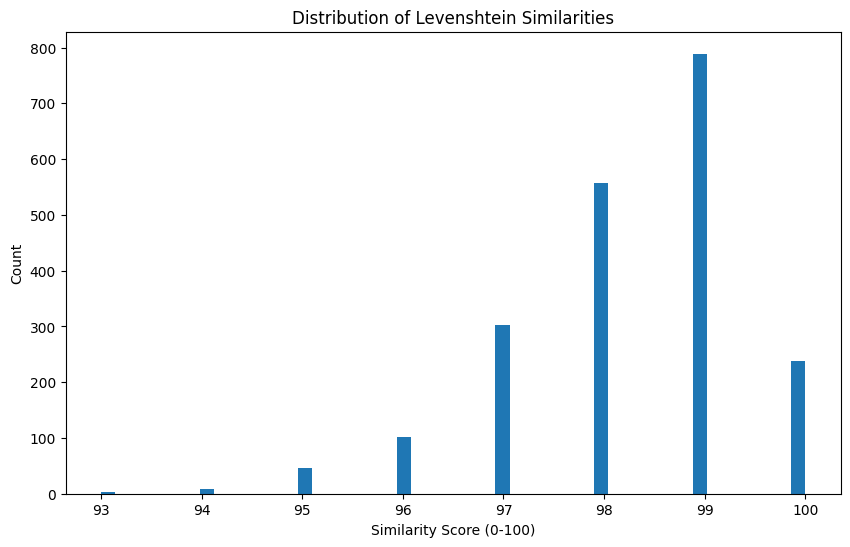

In [166]:
# Import Levenshtein distance from fuzzywuzzy
from fuzzywuzzy import fuzz

# Convert binary arrays to strings for Levenshtein distance calculation
def binary_array_to_string(arr):
    return ''.join(map(str, arr.astype(int)))

# Calculate Levenshtein distances for each sample
distances = []
for i in range(len(Z_test_decoded)):
    pred_str = binary_array_to_string(Z_test_decoded[i])
    true_str = binary_array_to_string(Y256[i])
    # Calculate normalized Levenshtein distance (0-100 score)
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)

# Convert to numpy array for analysis
distances = np.array(distances)

# Print summary statistics
print(f"Mean Levenshtein similarity: {np.mean(distances):.2f}")
print(f"Std dev Levenshtein similarity: {np.std(distances):.2f}")
print(f"Min Levenshtein similarity: {np.min(distances):.2f}")
print(f"Max Levenshtein similarity: {np.max(distances):.2f}")

# Plot histogram of distances
plt.figure(figsize=(10, 6))
plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

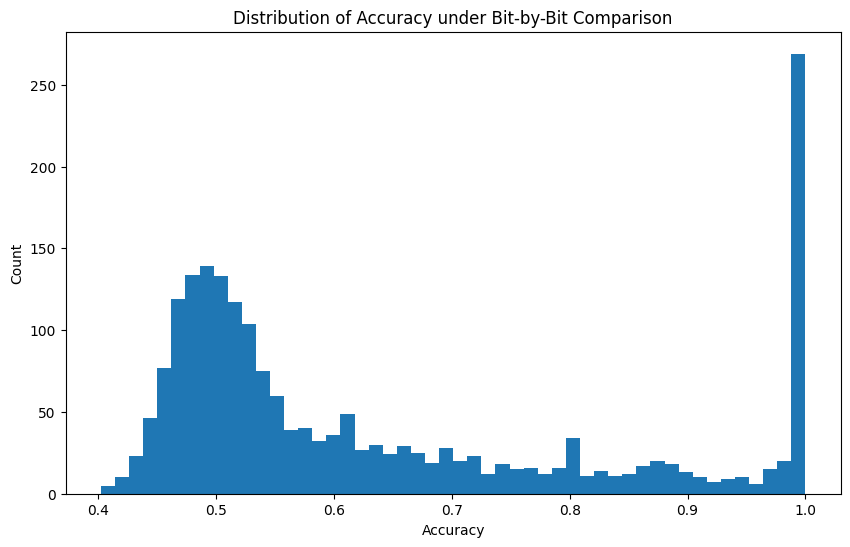

In [167]:
# compute the same statistic for accuracy under bit-by-bit comparison
acc_test_bit = np.mean(Z_test_decoded == Y256, axis=1)
# now plot a histogram of the accuracy under bit-by-bit comparison
plt.figure(figsize=(10, 6))
plt.hist(acc_test_bit, bins=50)
plt.title('Distribution of Accuracy under Bit-by-Bit Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Count')


((2048, 1000), (2048, 650))

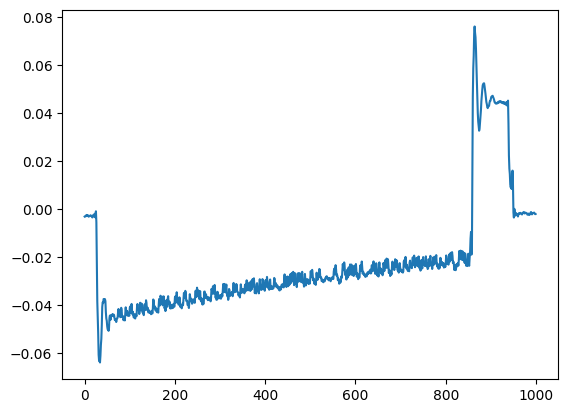

In [175]:
T_shifted = np.roll(T_resample, -50)
plt.plot(T_shifted[0])
T_shifted.shape, T.shape

64/64 [==============================] - 0s 7ms/step


Text(0, 0.5, 'Count')

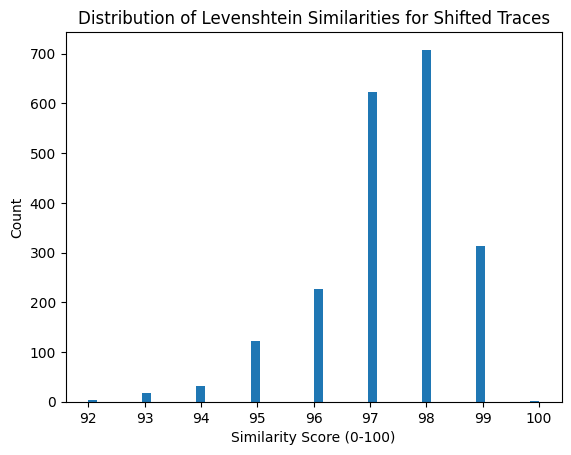

In [176]:
# predict the shifted traces, then decode, then compute the distribution of levenshtein distances
Z_test_shifted = unet_seg.predict(T_shifted, batch_size=32)
Z_test_decoded_shifted = K.ctc_decode(Z_test_shifted, 
                             input_length=np.ones(Z_test_shifted.shape[0]) * 1000,
                             greedy=True)[0][0].numpy()
Z_test_decoded_shifted = Z_test_decoded_shifted[:, 0:256]
distances_shifted = []
for i in range(len(Z_test_decoded_shifted)):
    pred_str = binary_array_to_string(Z_test_decoded_shifted[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances_shifted.append(distance)

distances_shifted = np.array(distances_shifted)
plt.hist(distances_shifted, bins=50)
plt.title('Distribution of Levenshtein Similarities for Shifted Traces (roll=-50)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')


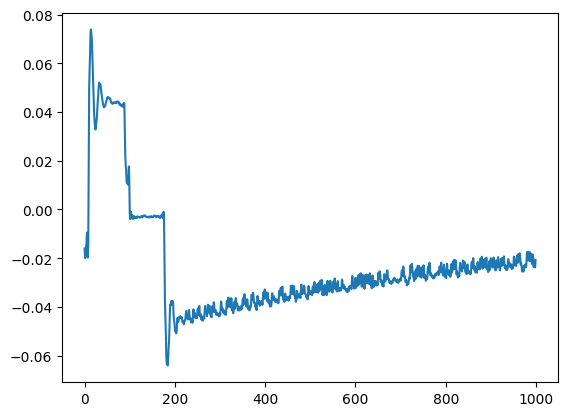

In [193]:
T_shifted = np.roll(T_resample, 100)
plt.plot(T_shifted[0])

64/64 [==============================] - 0s 7ms/step


Text(0, 0.5, 'Count')

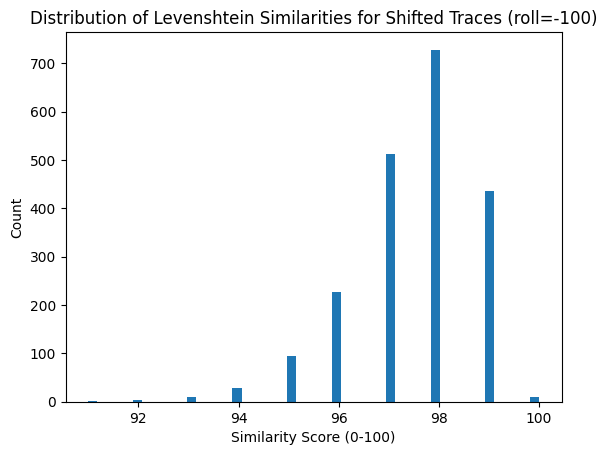

In [194]:
Z_test_shifted = unet_seg.predict(T_shifted, batch_size=32)
Z_test_decoded_shifted = K.ctc_decode(Z_test_shifted, 
                             input_length=np.ones(Z_test_shifted.shape[0]) * 1000,
                             greedy=True)[0][0].numpy()
Z_test_decoded_shifted = Z_test_decoded_shifted[:, 0:256]
distances_shifted = []
for i in range(len(Z_test_decoded_shifted)):
    pred_str = binary_array_to_string(Z_test_decoded_shifted[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances_shifted.append(distance)

distances_shifted = np.array(distances_shifted)
plt.hist(distances_shifted, bins=50)
plt.title('Distribution of Levenshtein Similarities for Shifted Traces (roll=-100)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

In [196]:
from complex_system_simulation import augment_trace

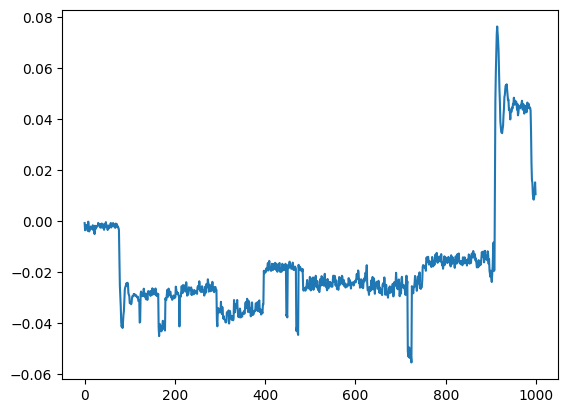

In [245]:
T_transformed = np.copy(T_resample)
custom_params = {
    "noise": {"std_dev": 0.001},
    "interrupts": {"num_interrupts": 5},
    "frequency_change": {"num_changes": 5, "max_slowdown": 1.5},
    "jitter": {"jitter_strength": 1},
    "enabled_augmentations": ["noise", "interrupts", "frequency_change", "jitter"]  # Only apply these transformations
}
for i in range(T_transformed.shape[0]):
    T_transformed[i] = augment_trace(T_transformed[i], custom_params)
plt.plot(T_transformed[0])


In [251]:
def analyze_transformed_traces(traces, labels, model, transform_params, batch_size=32, max_length=256, plot=True):
    """
    Analyze traces after applying transformations by predicting labels and calculating Levenshtein similarities.
    
    Args:
        traces: Input traces to transform and analyze
        labels: Ground truth labels to compare against
        model: Trained model for prediction
        transform_params: Dictionary specifying transformations to apply
        batch_size: Batch size for model prediction
        max_length: Maximum sequence length for predictions
        plot: Whether to plot histogram of similarities
        
    Returns:
        distances: Array of Levenshtein similarity scores
        transformed_traces: The transformed input traces
    """
    # Transform traces
    transformed_traces = np.copy(traces)
    for i in range(transformed_traces.shape[0]):
        transformed_traces[i] = augment_trace(transformed_traces[i], transform_params)
    
    # Get predictions
    predictions = model.predict(transformed_traces, batch_size=batch_size)
    # Use actual sequence length from input traces
    seq_length = transformed_traces.shape[1]
    decoded_preds = K.ctc_decode(predictions,
                                input_length=np.ones(predictions.shape[0]) * seq_length,
                                greedy=True)[0][0].numpy()
    decoded_preds = decoded_preds[:, 0:max_length]
    
    # Calculate similarities
    distances = []
    for i in range(len(decoded_preds)):
        pred_str = binary_array_to_string(decoded_preds[i])
        true_str = binary_array_to_string(labels[i])
        distance = fuzz.ratio(pred_str, true_str)
        distances.append(distance)
    distances = np.array(distances)
    
    # Optional plotting
    if plot:
        plt.hist(distances, bins=50)
        plt.title('Distribution of Levenshtein Similarities for Augmented Traces')
        plt.xlabel('Similarity Score (0-100)')
        plt.ylabel('Count')
        
    return distances, transformed_traces

64/64 [==============================] - 0s 7ms/step


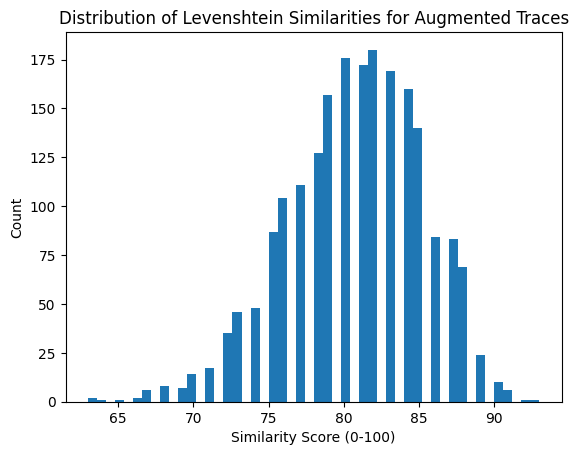

In [253]:
distances, transformed_traces = analyze_transformed_traces(T_resample, Y256, unet_seg, custom_params, batch_size=32, max_length=256, plot=True)


64/64 [==============================] - 0s 7ms/step


(array([99, 99, 99, ..., 98, 97, 98]),
 array([[-1.89759920e-03, -3.98487995e-03, -8.35046730e-04, ...,
          1.11121349e-02,  1.60183947e-02,  9.90120305e-03],
        [-1.52283057e-03, -3.55863942e-03,  7.10833871e-05, ...,
          1.30008254e-02,  1.81070471e-02,  1.11190349e-02],
        [-1.25780725e-03, -3.37059244e-03,  4.33746067e-06, ...,
          1.36606272e-02,  1.84693917e-02,  1.13499548e-02],
        ...,
        [-1.03684573e-03, -3.23434029e-03,  2.14775318e-05, ...,
          1.36025257e-02,  1.86497066e-02,  1.15210186e-02],
        [-5.38370397e-04, -2.67939801e-03,  8.13510190e-04, ...,
          1.31411884e-02,  1.84840051e-02,  1.19216450e-02],
        [-5.92497876e-04, -2.96109659e-03, -7.99215739e-05, ...,
          1.28413331e-02,  1.76295925e-02,  1.13380793e-02]]))

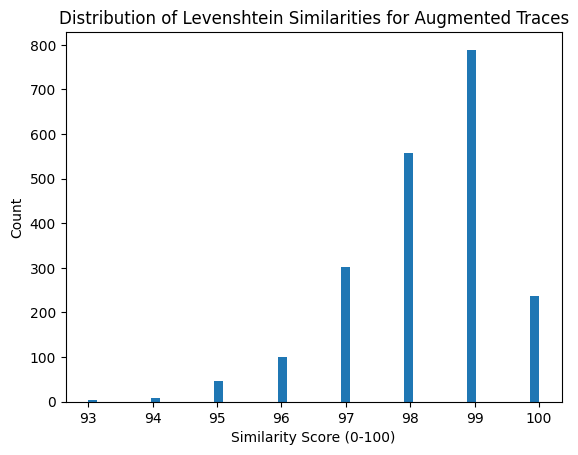

In [254]:
empty_params = {"enabled_augmentations":[]}
analyze_transformed_traces(T_resample, Y256, unet_seg, empty_params, batch_size=32, max_length=256, plot=True)

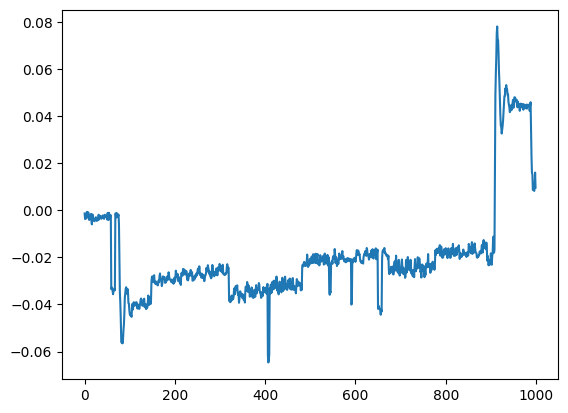

In [255]:
plt.plot(transformed_traces[0])

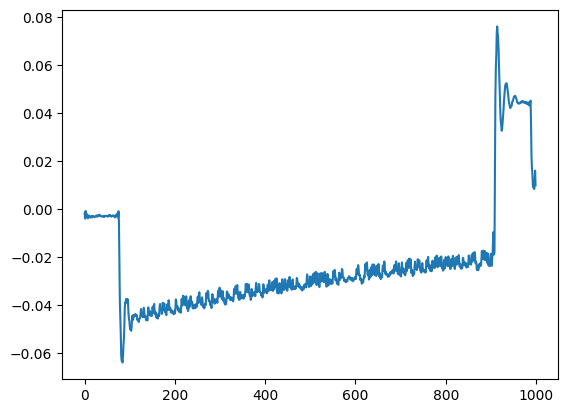

In [256]:
plt.plot(T_resample[0])

  0%|          | 0/2048 [00:00<?, ?it/s]

100%|██████████| 2048/2048 [00:00<00:00, 62032.39it/s]

17/64 [======>.......................] - ETA: 0s

64/64 [==============================] - 0s 7ms/step


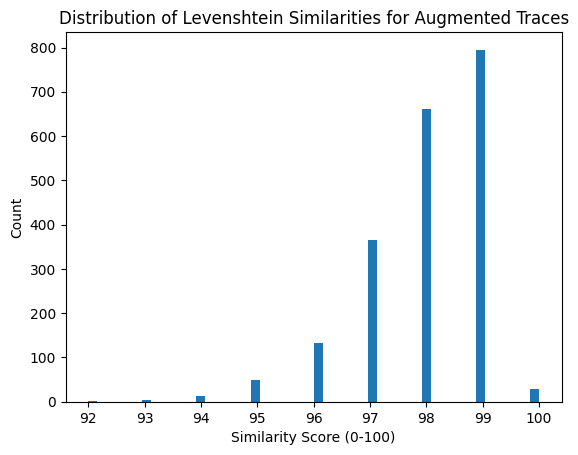

In [260]:
T2 = X_downsampled[:,850:1500]
T2_resample = resize_data(T2, 1000)
Y2 = Y[:,256:512]
distances, transformed_traces_2 = analyze_transformed_traces(T2_resample, Y2, unet_seg, empty_params, batch_size=32, max_length=256, plot=True)


64/64 [==============================] - 1s 8ms/step


(array([86, 86, 86, ..., 80, 79, 71]),
 array([[0.04084963, 0.03837149, 0.04059287, ..., 0.05797649, 0.0622126 ,
         0.05207948],
        [0.04038136, 0.03787635, 0.04168491, ..., 0.05723609, 0.06091871,
         0.05306104],
        [0.03843917, 0.0374283 , 0.04082738, ..., 0.0600628 , 0.06234482,
         0.05240944],
        ...,
        [0.04279765, 0.03795774, 0.04292982, ..., 0.05932054, 0.06060472,
         0.05251952],
        [0.04100692, 0.03694337, 0.04189365, ..., 0.06021622, 0.06299911,
         0.05318491],
        [0.03988465, 0.03743328, 0.04052701, ..., 0.05110385, 0.05464927,
         0.04850823]]))

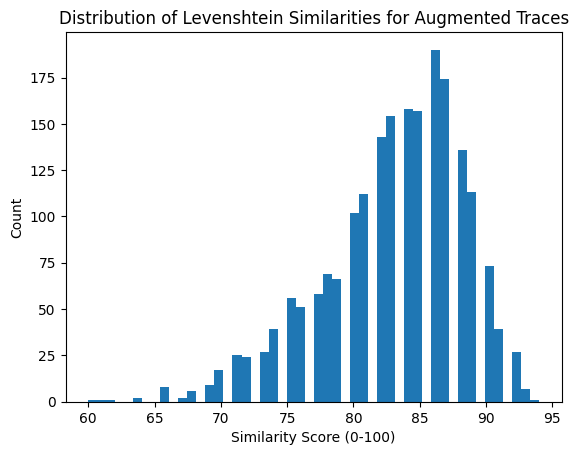

In [261]:
analyze_transformed_traces(T2_resample, Y2, unet_seg, custom_params, batch_size=32, max_length=256, plot=True)

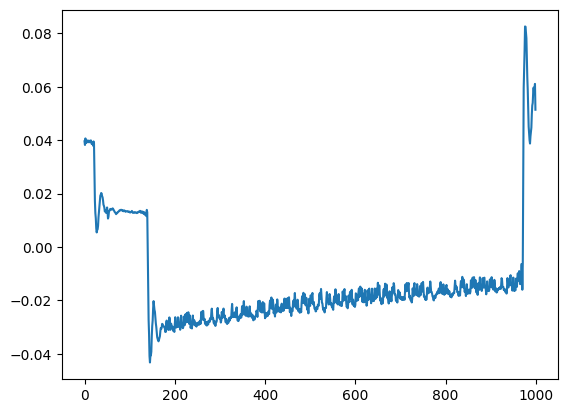

In [262]:
plt.plot(T2_resample[0])

In [ ]:
# TODO: The CM1 pretrained model is not included in this repository.
# You must obtain the CM1 data yourself, train or obtain this model,
# and update CM1_DATA_DIR (defined above) accordingly.
nc = ml.net_ches_2018(256, 5, 200, depth=20, output_activation='sigmoid')
nc.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
nc.load_weights(f'{CM1_DATA_DIR}/models/net_ches_depth20_1000samples_segmented_buffer50_share2.keras')
nc.summary()


Model: "model_39"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_22 (InputLayer)       [(None, 1000)]               0         []                            
                                                                                                  
 reshape_4 (Reshape)         (None, 5, 200)               0         ['input_22[0][0]']            
                                                                                                  
 batch_normalization_328 (B  (None, 5, 200)               800       ['reshape_4[0][0]']           
 atchNormalization)                                                                               
                                                                                                  
 conv1d_338 (Conv1D)         (None, 5, 256)               51456     ['batch_normalization_3

In [272]:
Z_nc = nc.predict(T_resample, batch_size=32)

64/64 [==============================] - 0s 2ms/step


Text(0, 0.5, 'Count')

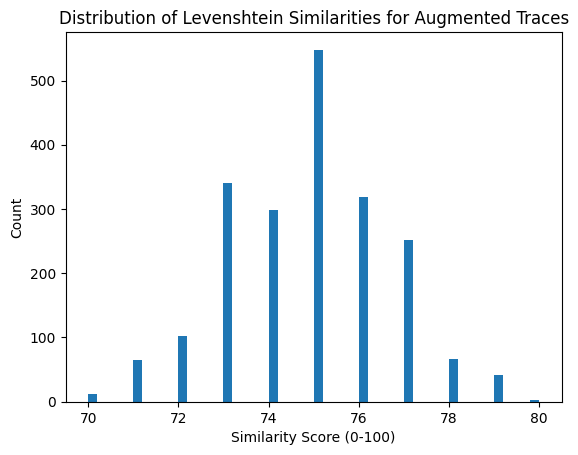

In [276]:
# compute Levenshtein distances
distances = []
for i in range(len(Z_nc)):
    pred_str = binary_array_to_string(Z_nc[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)
    
distances = np.array(distances)

plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities for Augmented Traces')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

In [278]:
nc.fit(Th_resample, Yh256, epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

Epoch 1/101
159/159 [==============================] - 2s 14ms/step - loss: 0.1834 - binary_accuracy: 0.9437 - val_loss: 0.2178 - val_binary_accuracy: 0.9242 - lr: 1.0000e-05
Epoch 2/101
159/159 [==============================] - 2s 14ms/step - loss: 0.1908 - binary_accuracy: 0.9391 - val_loss: 0.2278 - val_binary_accuracy: 0.9189 - lr: 1.0900e-04
Epoch 3/101
159/159 [==============================] - 3s 16ms/step - loss: 0.1982 - binary_accuracy: 0.9349 - val_loss: 0.2379 - val_binary_accuracy: 0.9152 - lr: 2.0800e-04
Epoch 4/101
159/159 [==============================] - 3s 17ms/step - loss: 0.2041 - binary_accuracy: 0.9319 - val_loss: 0.2473 - val_binary_accuracy: 0.9111 - lr: 3.0700e-04
Epoch 5/101
159/159 [==============================] - 2s 14ms/step - loss: 0.2087 - binary_accuracy: 0.9292 - val_loss: 0.2619 - val_binary_accuracy: 0.9059 - lr: 4.0600e-04
Epoch 6/101
159/159 [==============================] - 2s 13ms/step - loss: 0.2117 - binary_accuracy: 0.9278 - val_loss: 0.28

64/64 [==============================] - 0s 3ms/step


Text(0, 0.5, 'Count')

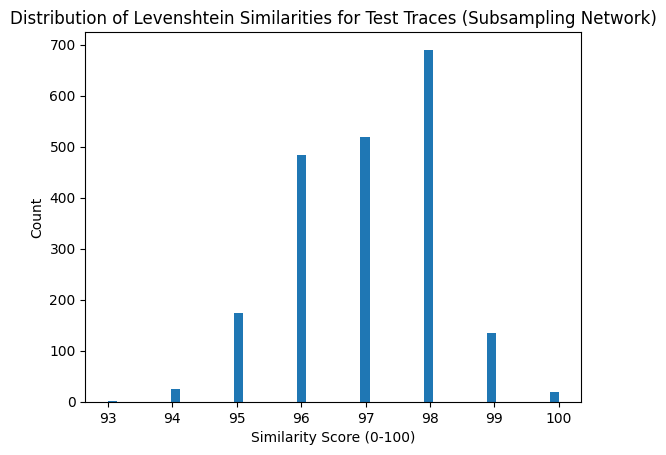

In [283]:
Z_nc = nc.predict(T_resample, batch_size=32)
Z_nc_decoded = (Z_nc > 0.5).astype(int)
# compute Levenshtein distances
distances = []
for i in range(len(Z_nc_decoded)):
    pred_str = binary_array_to_string(Z_nc_decoded[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)
    
distances = np.array(distances)

plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities for Test Traces (Subsampling Network)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

64/64 [==============================] - 0s 7ms/step


(array([99, 99, 99, ..., 98, 97, 98]),
 array([[-1.89759920e-03, -3.98487995e-03, -8.35046730e-04, ...,
          1.11121349e-02,  1.60183947e-02,  9.90120305e-03],
        [-1.52283057e-03, -3.55863942e-03,  7.10833871e-05, ...,
          1.30008254e-02,  1.81070471e-02,  1.11190349e-02],
        [-1.25780725e-03, -3.37059244e-03,  4.33746067e-06, ...,
          1.36606272e-02,  1.84693917e-02,  1.13499548e-02],
        ...,
        [-1.03684573e-03, -3.23434029e-03,  2.14775318e-05, ...,
          1.36025257e-02,  1.86497066e-02,  1.15210186e-02],
        [-5.38370397e-04, -2.67939801e-03,  8.13510190e-04, ...,
          1.31411884e-02,  1.84840051e-02,  1.19216450e-02],
        [-5.92497876e-04, -2.96109659e-03, -7.99215739e-05, ...,
          1.28413331e-02,  1.76295925e-02,  1.13380793e-02]]))

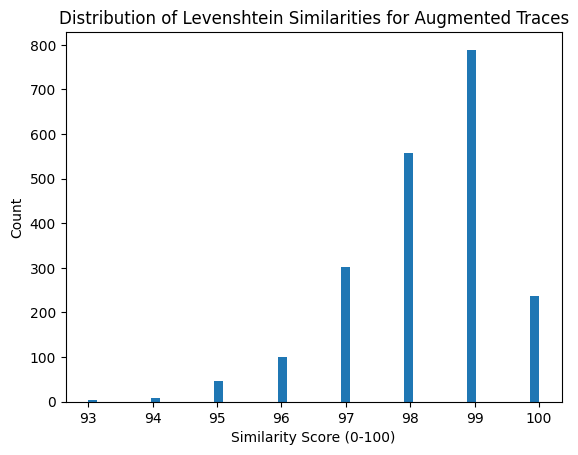

In [281]:
analyze_transformed_traces(T_resample, Y256, unet_seg, empty_params, batch_size=32, max_length=256, plot=True)


64/64 [==============================] - 0s 2ms/step


Text(0, 0.5, 'Count')

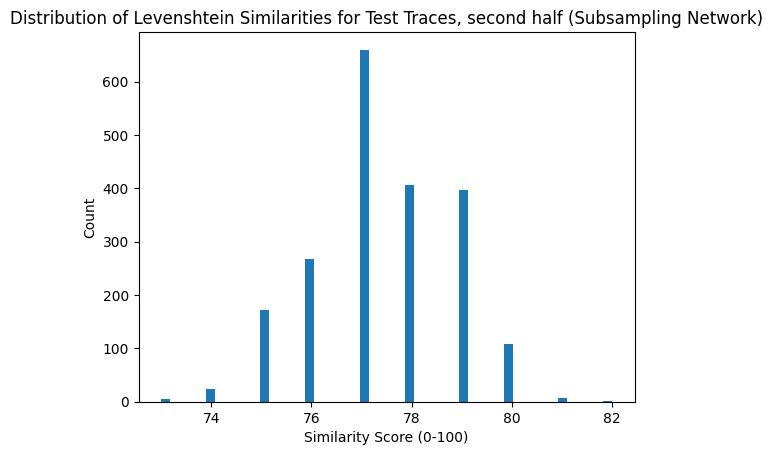

In [284]:
#Now let's try the subsampling network on the second half of the trace
Z2_nc = nc.predict(T2_resample, batch_size=32)
Z2_nc_decoded = (Z2_nc > 0.5).astype(int)
distances = []
for i in range(len(Z2_nc_decoded)):
    pred_str = binary_array_to_string(Z2_nc_decoded[i])
    true_str = binary_array_to_string(Y2[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)
    
distances = np.array(distances)

plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities for Test Traces, second half (Subsampling Network)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

64/64 [==============================] - 0s 8ms/step


(array([98, 97, 99, ..., 96, 97, 97]),
 array([[-0.01603318, -0.01993128, -0.01866771, ..., -0.02165095,
         -0.02379782, -0.02077006],
        [-0.01866275, -0.02281371, -0.02367766, ..., -0.02058459,
         -0.021576  , -0.01777103],
        [-0.01621417, -0.01960544, -0.02011963, ..., -0.02241764,
         -0.022911  , -0.01928116],
        ...,
        [-0.02184398, -0.02301912, -0.02179791, ..., -0.01810811,
         -0.0207357 , -0.01764885],
        [-0.01690702, -0.02051376, -0.01887307, ..., -0.01808294,
         -0.02007215, -0.01683807],
        [-0.0169661 , -0.02043543, -0.01910196, ..., -0.01798833,
         -0.0209255 , -0.01741449]]))

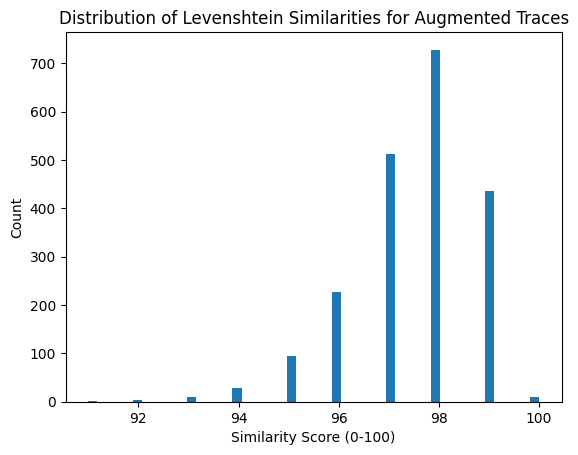

In [285]:
# Let's also try what happens if we use the first-half test traces, but rotate them by 100 samples
T_rotated = np.roll(T_resample, 100)
analyze_transformed_traces(T_rotated, Y256, unet_seg, empty_params, batch_size=32, max_length=256, plot=True)


64/64 [==============================] - 0s 3ms/step


Text(0, 0.5, 'Count')

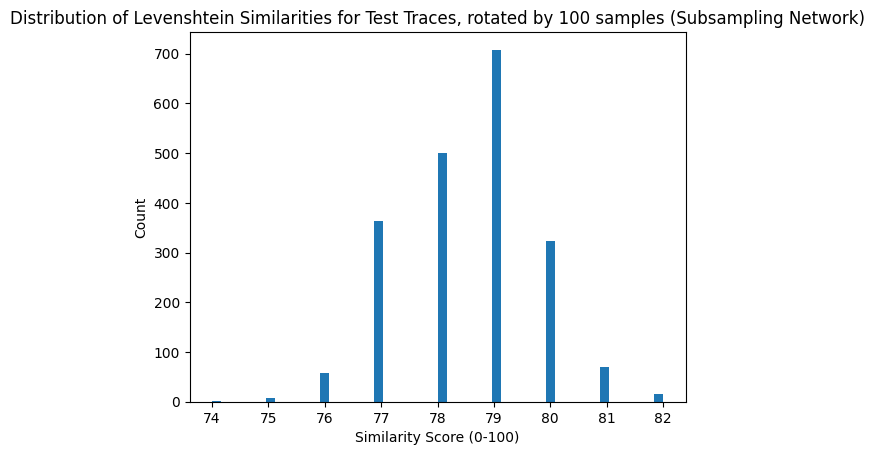

In [286]:
# Now let's see the same thing for the subsampling network
Z_rotated = nc.predict(T_rotated, batch_size=32)
Z_rotated_decoded = (Z_rotated > 0.5).astype(int)
distances = []
for i in range(len(Z_rotated_decoded)):
    pred_str = binary_array_to_string(Z_rotated_decoded[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)
    
distances = np.array(distances)

plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities for Test Traces, rotated by 100 samples (Subsampling Network)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')


64/64 [==============================] - 0s 3ms/step


Text(0, 0.5, 'Count')

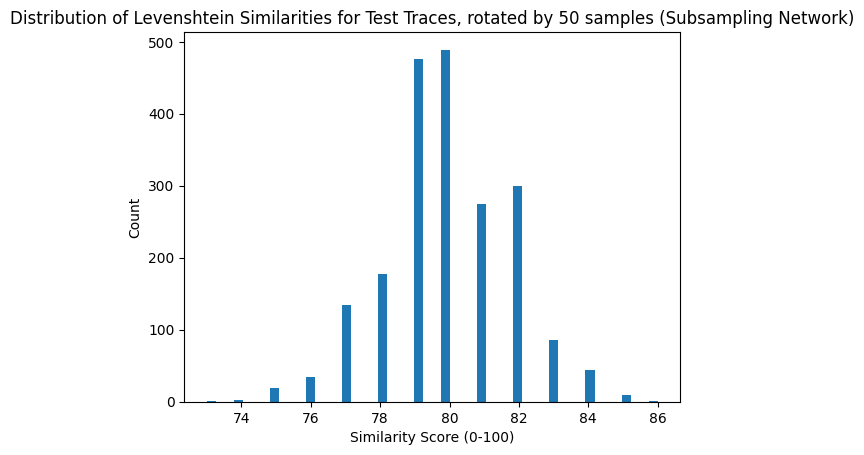

In [307]:
# That was too big a rotation amount, let's try 20 samples, subsampling network only
T_rotated = np.roll(T_resample, 1)
Z_rotated = nc.predict(T_rotated, batch_size=32)
Z_rotated_decoded = (Z_rotated > 0.5).astype(int)
distances = []
for i in range(len(Z_rotated_decoded)):
    pred_str = binary_array_to_string(Z_rotated_decoded[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)
    
distances = np.array(distances)

plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities for Test Traces, rotated by 50 samples (Subsampling Network)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

64/64 [==============================] - 0s 6ms/step


(array([98, 99, 99, ..., 97, 96, 96]),
 array([[ 0.01133808, -0.0018976 , -0.00398488, ...,  0.00834257,
          0.01111213,  0.01601839],
        [ 0.0099012 , -0.00152283, -0.00355864, ...,  0.0097136 ,
          0.01300083,  0.01810705],
        [ 0.01111903, -0.00125781, -0.00337059, ...,  0.01037803,
          0.01366063,  0.01846939],
        ...,
        [ 0.01163702, -0.00103685, -0.00323434, ...,  0.00989074,
          0.01360253,  0.01864971],
        [ 0.01152102, -0.00053837, -0.0026794 , ...,  0.00980945,
          0.01314119,  0.01848401],
        [ 0.01192165, -0.0005925 , -0.0029611 , ...,  0.01017292,
          0.01284133,  0.01762959]]))

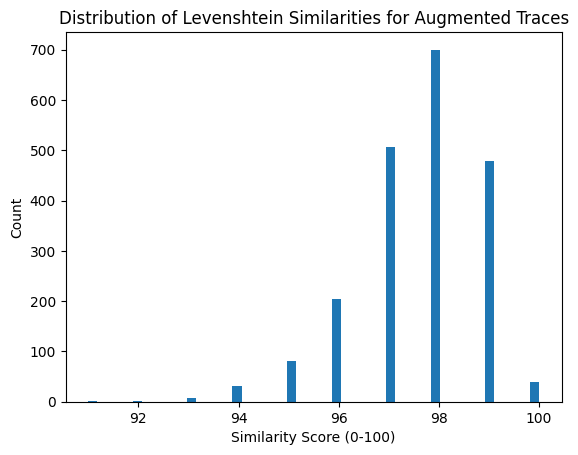

In [308]:
analyze_transformed_traces(T_rotated, Y256, unet_seg, empty_params, batch_size=32, max_length=256, plot=True)

In [309]:
T_rotated_random = np.roll(T_resample, np.random.randint(0,100))

64/64 [==============================] - 0s 7ms/step


(array([97, 98, 99, ..., 97, 97, 98]),
 array([[0.04582075, 0.04548667, 0.04557555, ..., 0.04681223, 0.04694177,
         0.04717917],
        [0.04724622, 0.04670222, 0.04628239, ..., 0.04572863, 0.04539955,
         0.04568416],
        [0.04612617, 0.04582809, 0.04554388, ..., 0.04741324, 0.04761632,
         0.04784372],
        ...,
        [0.04584769, 0.04536066, 0.04556773, ..., 0.04649039, 0.04674826,
         0.04715023],
        [0.04679454, 0.04630649, 0.04600918, ..., 0.04704288, 0.04731008,
         0.04773485],
        [0.04717034, 0.04663385, 0.04647147, ..., 0.04614412, 0.04590536,
         0.04594452]]))

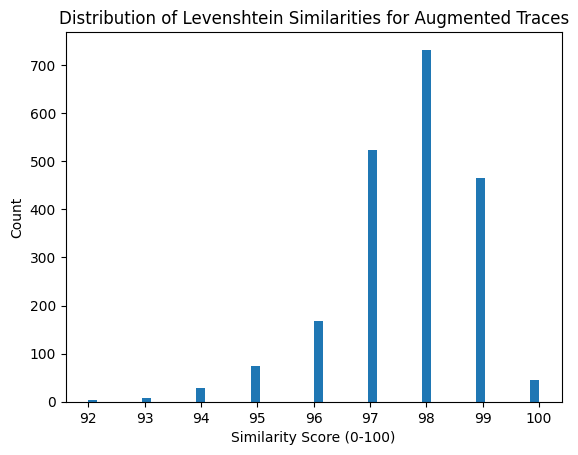

In [310]:
analyze_transformed_traces(T_rotated_random, Y256, unet_seg, empty_params, batch_size=32, max_length=256, plot=True)

64/64 [==============================] - 0s 2ms/step


Text(0, 0.5, 'Count')

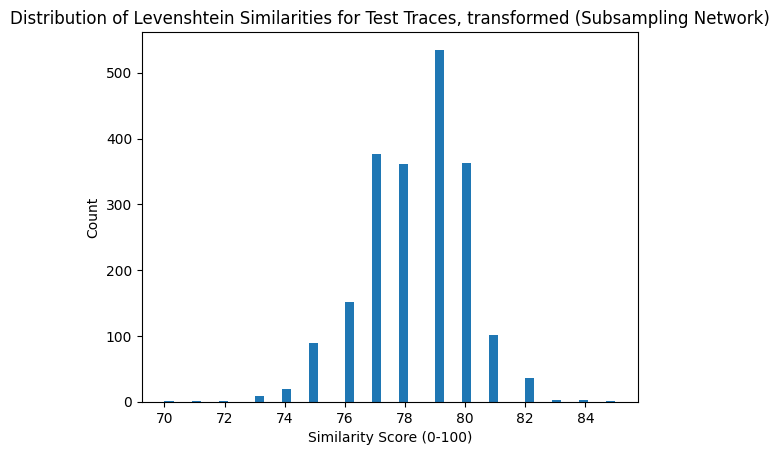

In [311]:
# let's finally test the subsampling network on the custom transformations
T_transformed = np.copy(T_resample)
for i in range(T_transformed.shape[0]):
    T_transformed[i] = augment_trace(T_transformed[i], custom_params)
Z_nc_transformed = nc.predict(T_transformed, batch_size=32)
Z_nc_transformed_decoded = (Z_nc_transformed > 0.5).astype(int)
distances = []
for i in range(len(Z_nc_transformed_decoded)):
    pred_str = binary_array_to_string(Z_nc_transformed_decoded[i])
    true_str = binary_array_to_string(Y256[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)
    
distances = np.array(distances)

plt.hist(distances, bins=50)
plt.title('Distribution of Levenshtein Similarities for Test Traces, transformed (Subsampling Network)')
plt.xlabel('Similarity Score (0-100)')
plt.ylabel('Count')

64/64 [==============================] - 0s 7ms/step


(array([88, 80, 85, ..., 87, 82, 83]),
 array([[-0.004176  , -0.00337652, -0.00016608, ...,  0.01222657,
          0.01885827,  0.00964917],
        [-0.00063811, -0.00448088, -0.00059696, ...,  0.01285917,
          0.0188213 ,  0.01117207],
        [-0.00098751, -0.00196366,  0.00064769, ...,  0.01380749,
          0.0178112 ,  0.01221979],
        ...,
        [-0.00115573, -0.0017451 , -0.00073027, ...,  0.01408162,
          0.0180742 ,  0.01013741],
        [-0.00060056, -0.00287447, -0.00031266, ...,  0.01239048,
          0.01675421,  0.01239258],
        [-0.00012473, -0.00411803,  0.00182702, ...,  0.01289958,
          0.01707981,  0.01318495]]))

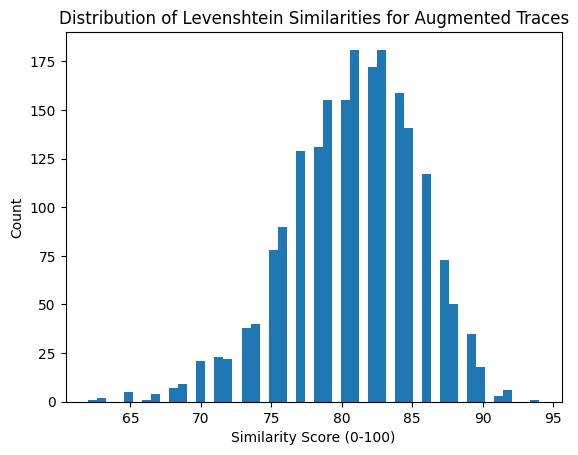

In [314]:
analyze_transformed_traces(T_resample, Y256, unet_seg, custom_params, batch_size=32, max_length=256, plot=True)

In [313]:
custom_params

{'noise': {'mean': 0, 'std_dev': 0.001},
 'interrupts': {'num_interrupts': 5, 'max_duration': 10},
 'frequency_change': {'num_changes': 5,
  'max_duration': 200,
  'max_slowdown': 1.5,
  'max_power_reduction': 0.5},
 'jitter': {'jitter_strength': 1},
 'enabled_augmentations': ['noise',
  'interrupts',
  'frequency_change',
  'jitter'],
 'time_warp': {'time_warp_strength': 0.1},
 'power_management': {'num_changes': 3},
 'context_switch': {'num_switches': 2, 'max_duration': 100}}